# Agent routing benchmark — insights

Plots for the V1 benchmark in `evals/`. Every figure is also saved to `evals/figures/` as a
PNG (for slides) and an SVG (for editing).

**To re-run on new results:** run the benchmark (`python -m evals.run_benchmark`, and
`--order-check`), then *Run All* here. By default the notebook picks the newest full run in
`evals/results/`; set `MAIN_RESULTS` / `ORDER_RESULTS` below to pin a specific file.

Strategies, as a reminder:

| | What the interaction agent (IA) sees | Who picks |
|---|---|---|
| **S0** | every agent's name + chat history (today's app) | IA |
| **S1** | every agent's card + chat history | IA |
| **S2** | nothing: no IA call | embedding search, or "new" below a threshold |
| **S3** | the 5 most similar cards + chat history | IA |

## Setup

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.ticker import FixedLocator, FuncFormatter, MultipleLocator, PercentFormatter

# The notebook lives in evals/; work out the folders from wherever Jupyter was started.
EVALS_DIR = Path.cwd() if (Path.cwd() / "bench.py").exists() else Path.cwd() / "evals"
REPO_DIR = EVALS_DIR.parent
RESULTS_DIR = EVALS_DIR / "results"
FIG_DIR = EVALS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

MAIN_RESULTS = None    # e.g. RESULTS_DIR / "20260923-051500.jsonl"; None = newest full run
ORDER_RESULTS = None   # None = newest order-check run
THEME = "light"        # "light" for slides with a white background, "dark" for dark slides

### Loading results

In [2]:
def load_rows(path):
    with open(path, encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def newest_results(kind):
    # kind "main": the newest file with the most Growth + Decay rows (so a smoke run never
    # hides a full run made earlier the same day). kind "order": the newest order-check file.
    best, best_count = None, 0
    for path in sorted(RESULTS_DIR.glob("*.jsonl"), key=os.path.getmtime, reverse=True):
        rows = load_rows(path)
        if kind == "order":
            if any(row.get("shuffle_seed") is not None for row in rows):
                return path
            continue
        count = sum(row.get("shuffle_seed") is None for row in rows)
        if count > best_count:
            best, best_count = path, count
    return best


main_path = MAIN_RESULTS or newest_results("main")
order_path = ORDER_RESULTS or newest_results("order")
print("main results :", main_path.name if main_path else None)
print("order results:", order_path.name if order_path else None)

REUSE_TESTS = ["easy_overlap", "semantic_disconnect", "related_context", "misleading_name", "elliptical_reference"]
TEST_ORDER = REUSE_TESTS + ["false_friend", "unrelated"]
TEST_NAMES = {
    "easy_overlap": "Easy overlap", "semantic_disconnect": "Semantic disconnect",
    "related_context": "Related context", "misleading_name": "Misleading name",
    "elliptical_reference": "Elliptical reference",
    "false_friend": "False friend", "unrelated": "Unrelated",
}
LEVELS = ["visible", "summarized", "gone"]


def prepare(rows):
    frame = pd.DataFrame(rows)
    frame["is_reuse"] = frame["test"].isin(REUSE_TESTS)
    wanted = np.where(frame["is_reuse"], "reuse_correct", "created")
    frame["correct"] = frame["outcome"] == wanted
    return frame


main = prepare([row for row in load_rows(main_path) if row.get("shuffle_seed") is None])
order = prepare([row for row in load_rows(order_path) if row.get("shuffle_seed") is not None]) if order_path else None
growth = main[main["experiment"] == "growth"]
decay = main[main["experiment"] == "decay"]
SIZES = sorted(growth["size"].unique())
STRATEGIES = [s for s in ["S0", "S1", "S2", "S3"] if s in set(main["strategy"])]

print(f"{len(main):,} rows · {len(growth):,} Growth · {len(decay):,} Decay · "
      f"errors: {(main['outcome'] == 'error').sum()} · asked the user: {(main['outcome'] == 'asked_user').sum()}")
print("Growth sizes:", SIZES, "· strategies:", STRATEGIES)
print("hosts that served the calls:", pd.Series([p for ps in main["providers"] for p in ps]).value_counts().to_dict())

main results : 20260923-063434.jsonl
order results: 20260923-063559.jsonl
3,320 rows · 2,880 Growth · 440 Decay · errors: 0 · asked the user: 67
Growth sizes: [np.int64(10), np.int64(50), np.int64(100), np.int64(250), np.int64(500), np.int64(1000)] · strategies: ['S0', 'S1', 'S2', 'S3']
hosts that served the calls: {'CoreWeave': 2524, 'Fireworks': 16, 'OpenInference': 1}


### Metrics

In [3]:
def summarize(frame, by):
    # The four headline metrics (plus cost) for every group in `by`.
    # Rows whose API call failed ("error") or where the IA asked the user a question
    # ("asked_user") are left out of every rate, as in report.py.
    out = []
    for key, group in frame.groupby(by, sort=True):
        key = key if isinstance(key, tuple) else (key,)
        answered = group[group["outcome"] != "error"]
        scored = answered[answered["outcome"] != "asked_user"]
        reuse = scored[scored["is_reuse"]]
        create = scored[~scored["is_reuse"]]
        calls = scored["model_calls"].sum()
        out.append({
            **dict(zip(by, key)),
            "reuse_accuracy": (reuse["outcome"] == "reuse_correct").mean() if len(reuse) else np.nan,
            "create_accuracy": (create["outcome"] == "created").mean() if len(create) else np.nan,
            "wrong_reuse_rate": (scored["outcome"] == "reuse_wrong").mean() if len(scored) else np.nan,
            "unnecessary_new_rate": (reuse["outcome"] == "created").mean() if len(reuse) else np.nan,
            "no_dispatch_rate": (scored["outcome"] == "no_dispatch").mean() if len(scored) else np.nan,
            "asked_rate": (answered["outcome"] == "asked_user").mean() if len(answered) else np.nan,
            "overall_accuracy": scored["correct"].mean() if len(scored) else np.nan,
            "prompt_tokens_per_call": scored["tokens_in"].sum() / calls if calls else np.nan,
            "cost_per_1k_requests": scored["cost"].mean() * 1000 if len(scored) else np.nan,
            "reuse_cases": len(reuse),
            "create_cases": len(create),
        })
    return pd.DataFrame(out)


growth_table = summarize(growth, ["strategy", "size"])
decay_table = summarize(decay[decay["is_reuse"] & (decay["test"] != "elliptical_reference")], ["strategy", "level"])
growth_table.round(3)

,strategy,size,reuse_accuracy,create_accuracy,wrong_reuse_rate,unnecessary_new_rate,no_dispatch_rate,asked_rate,overall_accuracy,prompt_tokens_per_call,cost_per_1k_requests,reuse_cases,create_cases
0,S0,10,0.500,0.900,0.083,0.412,0.008,0.000,0.633,3728.750,0.982,80,40
1,S0,50,0.474,0.974,0.096,0.395,0.000,0.042,0.643,4160.916,1.098,76,39
2,S0,100,0.432,0.872,0.088,0.486,0.009,0.058,0.584,4696.730,1.216,74,39
3,S0,250,0.360,0.923,0.053,0.587,0.009,0.050,0.553,6322.948,1.541,75,39
4,S0,500,0.380,0.975,0.027,0.592,0.000,0.075,0.595,9059.286,2.076,71,40
5,S0,1000,0.333,0.949,0.036,0.625,0.009,0.075,0.550,14545.752,3.215,72,39
6,S1,10,0.987,1.000,0.000,0.013,0.000,0.017,0.992,4160.345,1.095,78,40
7,S1,50,0.962,1.000,0.000,0.025,0.008,0.008,0.975,6183.787,1.523,80,39
8,S1,100,0.962,1.000,0.000,0.038,0.000,0.008,0.975,8659.208,1.978,80,39
9,S1,250,0.925,0.974,0.000,0.075,0.008,0.008,0.941,16243.967,3.525,80,39


### Style

In [4]:
# Colours come from a validated, colour-blind-safe palette (checked with the dataviz
# validator): strategies use the first four categorical slots in a fixed order, and each
# strategy also has its own marker shape, so identity never relies on colour alone.
THEMES = {
    "light": dict(
        surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", muted="#898781", grid="#e1e0d9", axis="#c3c2b7",
        series=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"],
        ordinal=["#86b6ef", "#2a78d6", "#104281"],
        sequential=["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
        good="#0ca30c", warning="#fab219", serious="#ec835a", critical="#d03b3b", neutral="#d6d5ce",
    ),
    "dark": dict(
        surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7", muted="#898781", grid="#2c2c2a", axis="#383835",
        series=["#3987e5", "#d95926", "#199e70", "#c98500"],
        ordinal=["#184f95", "#3987e5", "#9ec5f4"],
        sequential=["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4", "#cde2fb"],
        good="#0ca30c", warning="#fab219", serious="#ec835a", critical="#d03b3b", neutral="#52514e",
    ),
}
T = THEMES[THEME]

COLOR = dict(zip(["S0", "S1", "S2", "S3"], T["series"]))
MARKER = {"S0": "o", "S1": "s", "S2": "D", "S3": "^"}
NAME = {"S0": "S0 · names", "S1": "S1 · all cards", "S2": "S2 · embeddings only", "S3": "S3 · top-5 + IA"}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "figure.facecolor": T["surface"], "axes.facecolor": T["surface"], "savefig.facecolor": T["surface"],
    "text.color": T["ink"], "axes.labelcolor": T["ink2"], "axes.edgecolor": T["axis"],
    "xtick.color": T["muted"], "ytick.color": T["muted"], "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": T["grid"], "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": T["ink"],
    "axes.titlelocation": "left", "axes.titlepad": 10, "legend.frameon": False,
    "xtick.major.size": 0, "ytick.major.size": 0, "savefig.dpi": 200,
})


def new_figure(title, subtitle, nrows=1, ncols=1, size=(12, 6.75), sharey=False, top=0.78):
    # A 16:9 figure with a left-aligned title and subtitle above the plots.
    fig, axes = plt.subplots(nrows, ncols, figsize=size, sharey=sharey, squeeze=False)
    fig.text(0.055, 0.965, title, fontsize=18, weight="bold", color=T["ink"], ha="left", va="top")
    fig.text(0.055, 0.905, subtitle, fontsize=11.5, color=T["ink2"], ha="left", va="top")
    fig.subplots_adjust(top=top, left=0.075, right=0.87, bottom=0.12, wspace=0.3, hspace=0.55)
    return fig, axes


def strategy_legend(fig, strategies, y=0.855):
    handles = [Line2D([0], [0], color=COLOR[s], marker=MARKER[s], lw=2.2, ms=7,
                      markeredgecolor=T["surface"], markeredgewidth=1.5, label=NAME[s]) for s in strategies]
    fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.05, y), ncol=len(handles),
               fontsize=11, handlelength=2.4, columnspacing=2.0, labelcolor=T["ink2"])


def percent_axis(ax, low=0.0, values=None):
    # Accuracy axis. Pass `values` to zoom in: lines don't need a zero baseline, and a 0-100%
    # axis flattens lines that all sit between 80% and 100%.
    if values is not None:
        values = [v for v in values if not np.isnan(v)]
        low = max(0.0, np.floor((min(values) - 0.05) * 10) / 10)
    ax.set_ylim(low, 1.02)
    ax.yaxis.set_major_locator(MultipleLocator(0.1 if low >= 0.5 else 0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))


def rate_axis(ax, values):
    # Axis for small rates (wrong reuse, unnecessary new) with clean whole-percent ticks.
    top = max(0.1, float(np.nanmax(values)) * 1.25)
    ax.set_ylim(0, top)
    ax.yaxis.set_major_locator(MultipleLocator(0.02 if top <= 0.15 else 0.05))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))


def agents_axis(ax, sizes=None, label=True):
    sizes = sizes or SIZES
    ax.set_xscale("log")
    ax.set_xticks(sizes)
    ax.set_xticklabels([f"{s:,}" for s in sizes])
    ax.minorticks_off()
    ax.set_xlim(sizes[0] * 0.8, sizes[-1] * 1.25)
    if label:
        ax.set_xlabel("Agents in the roster (log scale)")


def strategy_lines(ax, table, x, y, strategies, end_labels=True, fmt="{:.0%}", min_gap=0.06):
    # One 2px line per strategy with ringed markers. End labels only where they don't collide.
    ends = []
    for s in strategies:
        sub = table[table["strategy"] == s].sort_values(x)
        sub = sub[sub[y].notna()]
        if sub.empty:
            continue
        ax.plot(sub[x], sub[y], color=COLOR[s], lw=2.2, marker=MARKER[s], ms=7, mec=T["surface"], mew=1.6,
                solid_capstyle="round", solid_joinstyle="round", zorder=3)
        ends.append((sub[y].iloc[-1], sub[x].iloc[-1], s))
    if end_labels and ends:
        lo, hi = ax.get_ylim()
        placed = []
        for value, xpos, s in sorted(ends):
            if all(abs(value - other) / (hi - lo) >= min_gap for other in placed):
                ax.annotate(f"{s}  {fmt.format(value)}", (xpos, value), xytext=(10, 0), textcoords="offset points",
                            va="center", ha="left", fontsize=10.5, color=T["ink2"], annotation_clip=False)
                placed.append(value)


def finish(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    fig.savefig(FIG_DIR / f"{name}.svg")
    plt.show()


def ink_for(fill):
    r, g, b = to_rgb(fill)
    return "#0b0b0b" if (0.2126 * r + 0.7152 * g + 0.0722 * b) > 0.55 else "#ffffff"

---
## 1. Growth: what does roster size do?

Every case uses the same short chat, which never mentions the agent the case is about, so the
IA has to find it from the agent list alone. Only the number of filler agents changes, so any
change along the x-axis is the effect of roster size alone. Fillers are realistic competitors
(other emails, invoices, trips), not random noise.

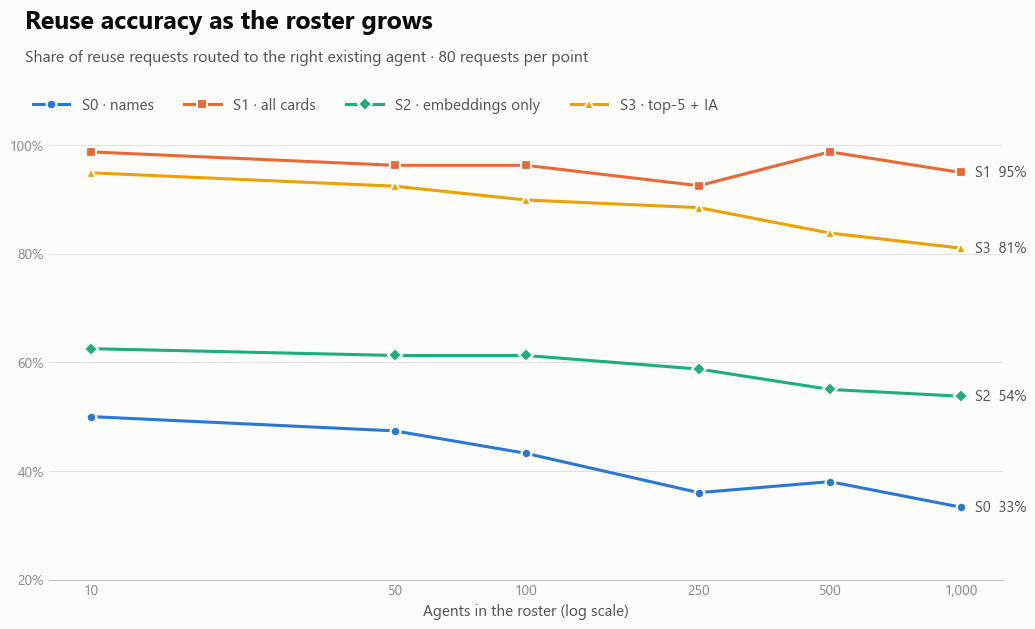

In [5]:
n_reuse = int(growth_table["reuse_cases"].max())
fig, axes = new_figure("Reuse accuracy as the roster grows",
                       f"Share of reuse requests routed to the right existing agent · {n_reuse} requests per point")
ax = axes[0, 0]
percent_axis(ax, values=growth_table["reuse_accuracy"])
agents_axis(ax)
strategy_lines(ax, growth_table, "size", "reuse_accuracy", STRATEGIES)
strategy_legend(fig, STRATEGIES)
finish(fig, "01_growth_reuse_accuracy")

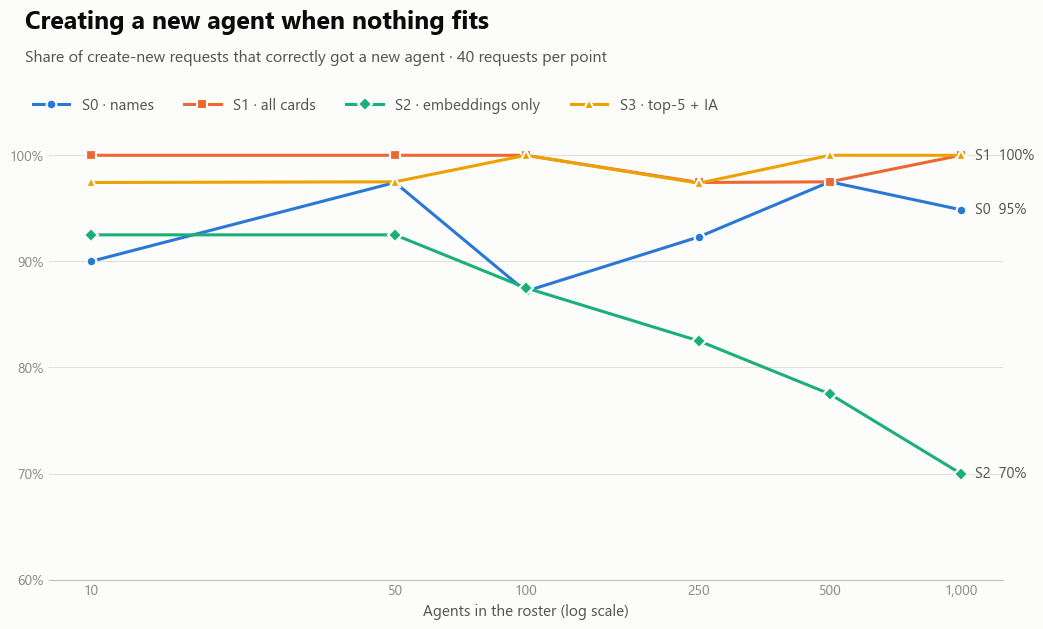

In [6]:
n_create = int(growth_table["create_cases"].max())
fig, axes = new_figure("Creating a new agent when nothing fits",
                       f"Share of create-new requests that correctly got a new agent · {n_create} requests per point")
ax = axes[0, 0]
percent_axis(ax, values=growth_table["create_accuracy"])
agents_axis(ax)
strategy_lines(ax, growth_table, "size", "create_accuracy", STRATEGIES)
strategy_legend(fig, STRATEGIES)
finish(fig, "02_growth_create_accuracy")

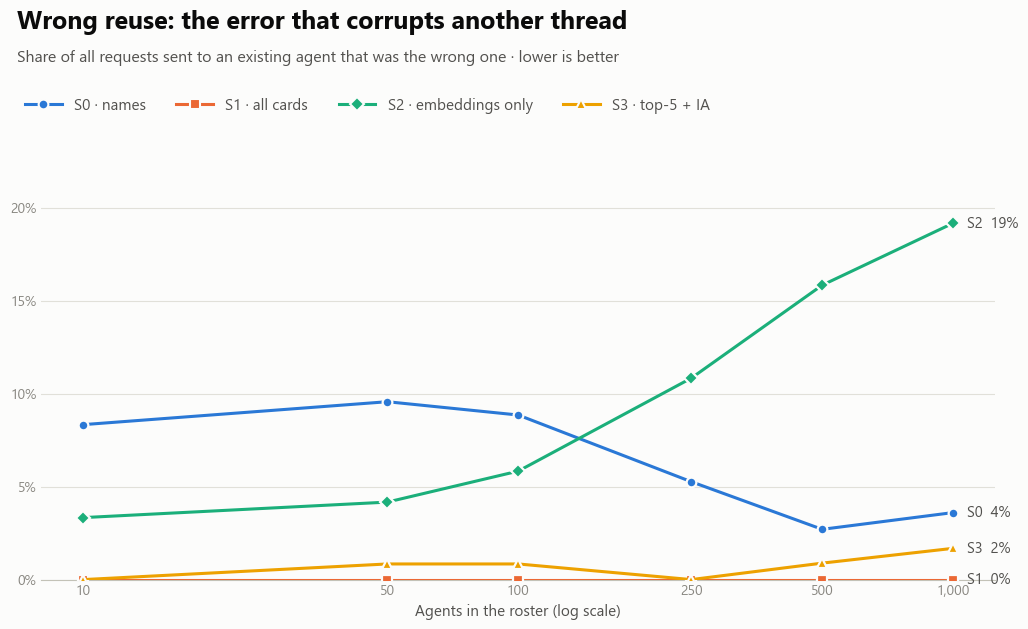

In [7]:
fig, axes = new_figure("Wrong reuse: the error that corrupts another thread",
                       "Share of all requests sent to an existing agent that was the wrong one · lower is better")
ax = axes[0, 0]
rate_axis(ax, growth_table["wrong_reuse_rate"])
agents_axis(ax)
strategy_lines(ax, growth_table, "size", "wrong_reuse_rate", STRATEGIES)
strategy_legend(fig, STRATEGIES)
finish(fig, "03_growth_wrong_reuse")

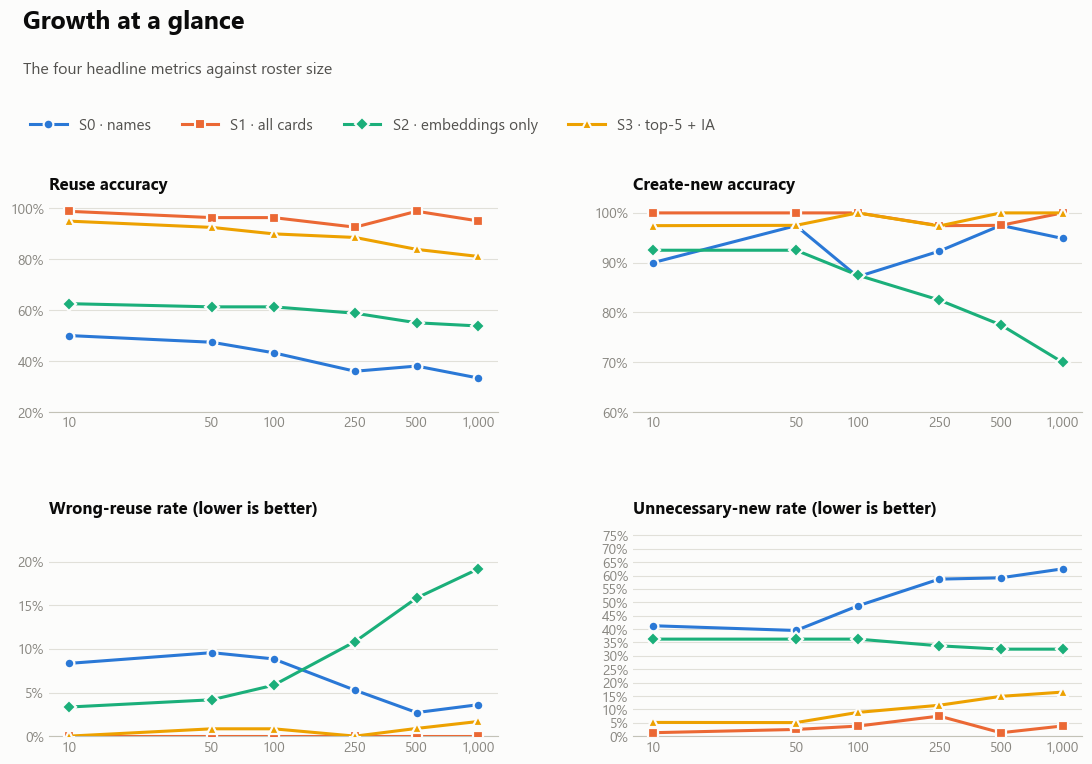

In [8]:
panels = [("reuse_accuracy", "Reuse accuracy", True), ("create_accuracy", "Create-new accuracy", True),
          ("wrong_reuse_rate", "Wrong-reuse rate (lower is better)", False),
          ("unnecessary_new_rate", "Unnecessary-new rate (lower is better)", False)]
fig, axes = new_figure("Growth at a glance", "The four headline metrics against roster size",
                       nrows=2, ncols=2, size=(13, 8.6), top=0.74)
for ax, (metric, title, full) in zip(axes.flat, panels):
    ax.set_title(title)
    if full:
        percent_axis(ax, values=growth_table[metric])
    else:
        rate_axis(ax, growth_table[metric])
    agents_axis(ax, label=False)
    strategy_lines(ax, growth_table, "size", metric, STRATEGIES, end_labels=False)
strategy_legend(fig, STRATEGIES, y=0.855)
finish(fig, "04_growth_overview")

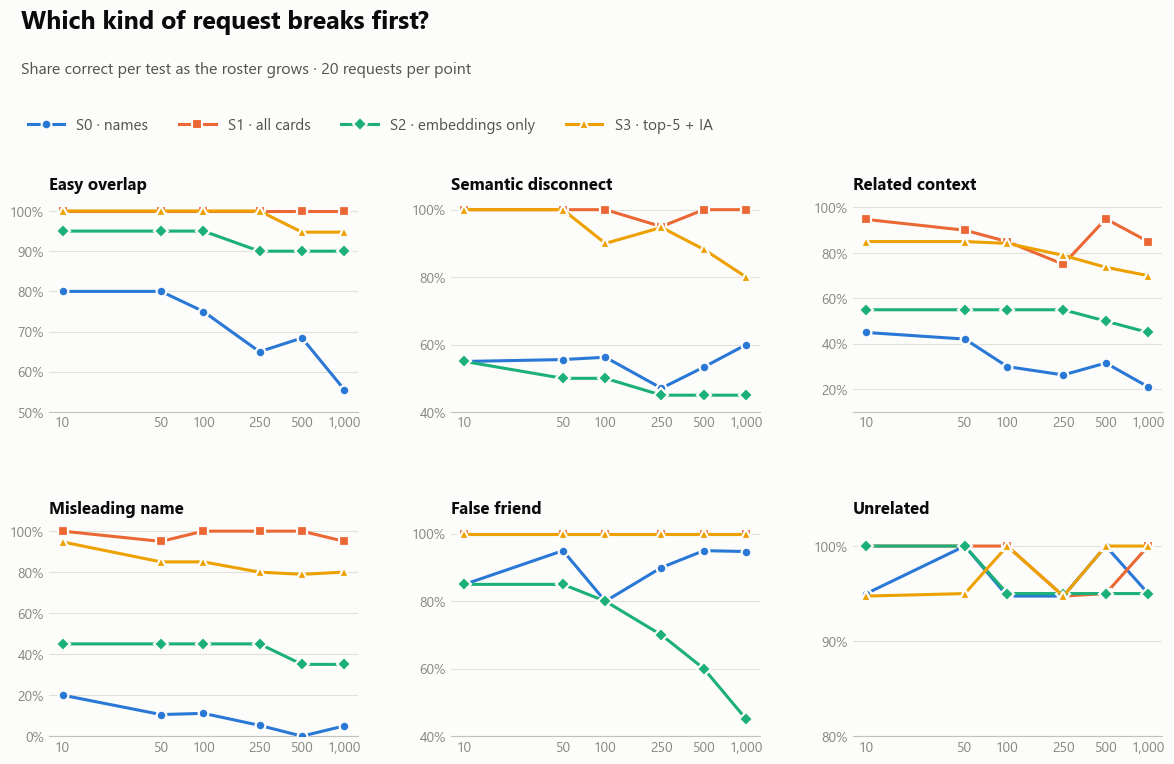

In [9]:
by_test = summarize(growth, ["strategy", "size", "test"])
by_test["correct"] = np.where(by_test["test"].isin(REUSE_TESTS), by_test["reuse_accuracy"], by_test["create_accuracy"])
growth_tests = [t for t in TEST_ORDER if t in set(by_test["test"])]
fig, axes = new_figure("Which kind of request breaks first?",
                       "Share correct per test as the roster grows · 20 requests per point",
                       nrows=2, ncols=3, size=(14, 8.6), top=0.74)
for ax, test in zip(axes.flat, growth_tests):
    ax.set_title(TEST_NAMES[test])
    percent_axis(ax, values=by_test[by_test["test"] == test]["correct"])
    agents_axis(ax, label=False)
    strategy_lines(ax, by_test[by_test["test"] == test], "size", "correct", STRATEGIES, end_labels=False)
for ax in list(axes.flat)[len(growth_tests):]:
    ax.axis("off")
strategy_legend(fig, STRATEGIES, y=0.855)
finish(fig, "05_growth_by_test")

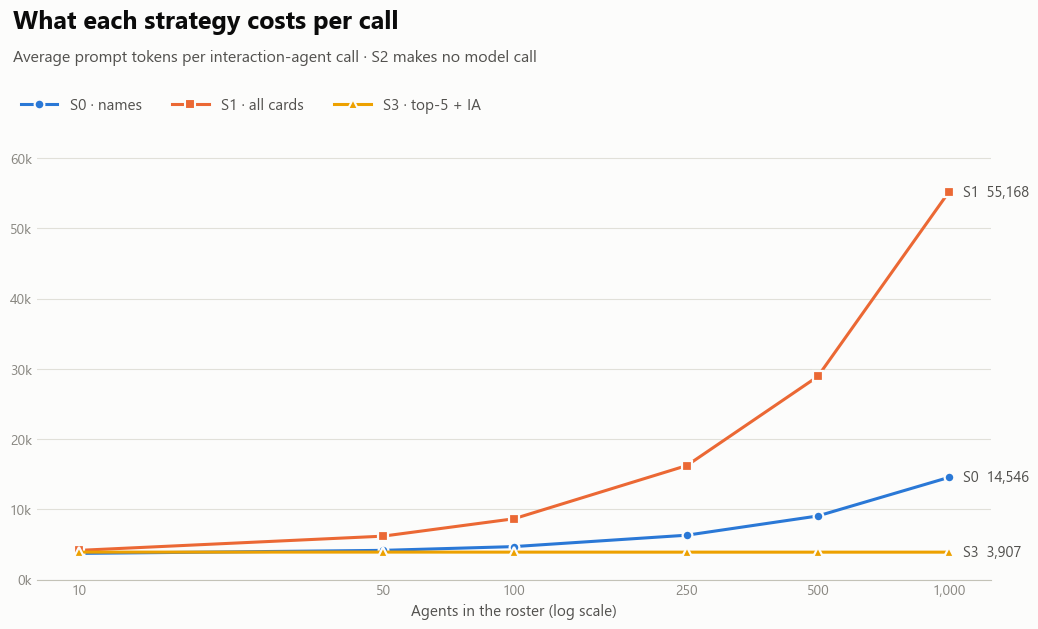

In [10]:
ia = [s for s in STRATEGIES if s != "S2"]
fig, axes = new_figure("What each strategy costs per call",
                       "Average prompt tokens per interaction-agent call · S2 makes no model call")
ax = axes[0, 0]
agents_axis(ax)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax.set_ylim(0, float(growth_table["prompt_tokens_per_call"].max()) * 1.15)
strategy_lines(ax, growth_table, "size", "prompt_tokens_per_call", ia, fmt="{:,.0f}", min_gap=0.04)
strategy_legend(fig, ia)
finish(fig, "06_growth_prompt_tokens")

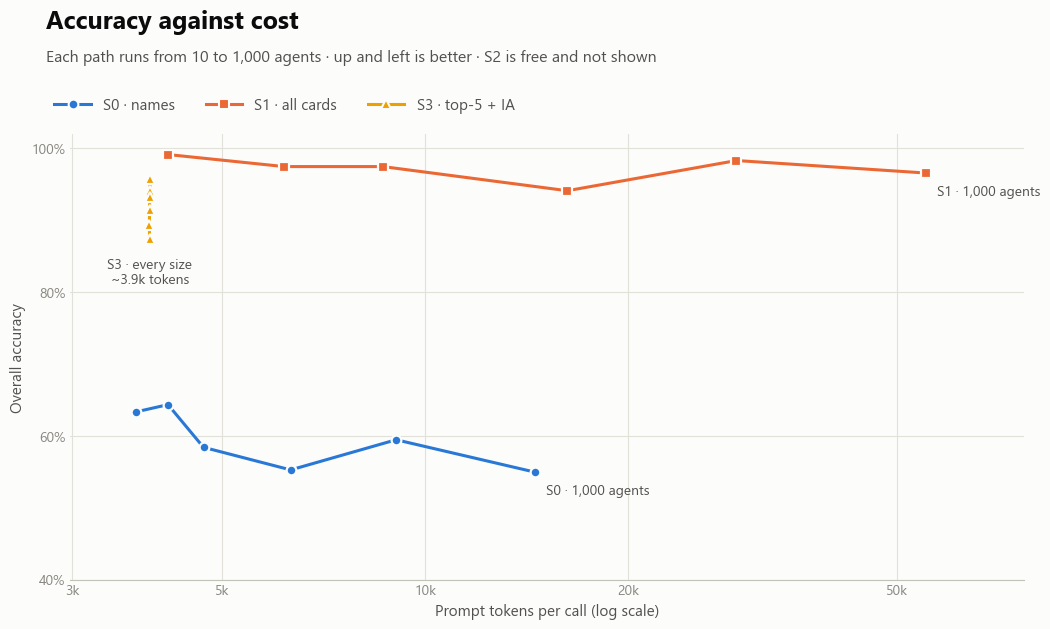

In [11]:
fig, axes = new_figure("Accuracy against cost",
                       "Each path runs from 10 to 1,000 agents · up and left is better · S2 is free and not shown")
ax = axes[0, 0]
for s in ia:
    sub = growth_table[growth_table["strategy"] == s].sort_values("size")
    ax.plot(sub["prompt_tokens_per_call"], sub["overall_accuracy"], color=COLOR[s], lw=2.2, marker=MARKER[s],
            ms=7, mec=T["surface"], mew=1.6, zorder=3)
    spread = sub["prompt_tokens_per_call"].max() / sub["prompt_tokens_per_call"].min()
    if spread < 1.3:
        # The prompt doesn't grow, so every size sits in the same spot: one label is enough.
        ax.annotate(f"{s} · every size\n~{sub['prompt_tokens_per_call'].mean() / 1000:.1f}k tokens",
                    (sub["prompt_tokens_per_call"].mean(), sub["overall_accuracy"].min()),
                    xytext=(0, -14), textcoords="offset points", ha="center", va="top", fontsize=10, color=T["ink2"])
        continue
    row = sub.iloc[-1]
    ax.annotate(f"{s} · {int(row['size']):,} agents", (row["prompt_tokens_per_call"], row["overall_accuracy"]),
                xytext=(8, -16), textcoords="offset points", fontsize=10, color=T["ink2"])
ax.set_xscale("log")
largest_tokens = growth_table["prompt_tokens_per_call"].max()
ax.xaxis.set_major_locator(FixedLocator([v for v in [3000, 5000, 10000, 20000, 50000] if v <= largest_tokens * 1.5]))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k"))
ax.set_xlim(growth_table["prompt_tokens_per_call"].min() * 0.8, largest_tokens * 1.4)
ax.set_xlabel("Prompt tokens per call (log scale)")
ax.grid(True, axis="both")
percent_axis(ax, values=growth_table.loc[growth_table["strategy"].isin(ia), "overall_accuracy"])
ax.set_ylabel("Overall accuracy")
strategy_legend(fig, ia)
finish(fig, "07_accuracy_vs_cost")

---
## 2. Decay: what does losing history do?

Roster fixed at 100 agents. Each reuse request is labelled by what the history still says
about its agent: **visible** (its result is still word for word in the chat), **summarized**
(only the summary mentions it) or **gone**. Elliptical requests are left out here because
they only exist at *visible*; they get their own panel below.

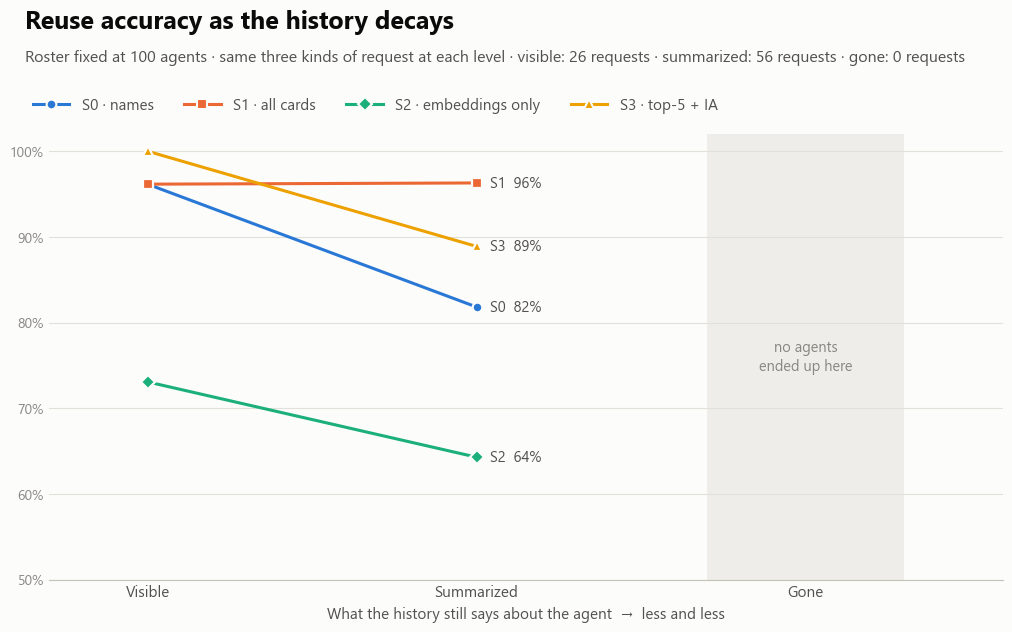

In [12]:
level_positions = {level: i for i, level in enumerate(LEVELS)}
table = decay_table.copy()
table["x"] = table["level"].map(level_positions)
counts = decay[decay["is_reuse"] & (decay["test"] != "elliptical_reference")].groupby("level")["case_id"].nunique()
fig, axes = new_figure("Reuse accuracy as the history decays",
                       "Roster fixed at 100 agents · same three kinds of request at each level · "
                       + " · ".join(f"{level}: {counts.get(level, 0)} requests" for level in LEVELS))
ax = axes[0, 0]
percent_axis(ax, values=table["reuse_accuracy"])
strategy_lines(ax, table, "x", "reuse_accuracy", STRATEGIES)
ax.set_xticks(range(len(LEVELS)))
ax.set_xticklabels([level.capitalize() for level in LEVELS], fontsize=11, color=T["ink2"])
ax.set_xlim(-0.3, len(LEVELS) - 0.4)
ax.set_xlabel("What the history still says about the agent  →  less and less")
for level in LEVELS:
    if counts.get(level, 0) == 0:
        x = level_positions[level]
        ax.axvspan(x - 0.3, x + 0.3, color=T["grid"], alpha=0.5, lw=0)
        ax.text(x, sum(ax.get_ylim()) / 2, "no agents\nended up here", ha="center", va="center", fontsize=10.5, color=T["muted"])
strategy_legend(fig, STRATEGIES)
finish(fig, "08_decay_by_level")

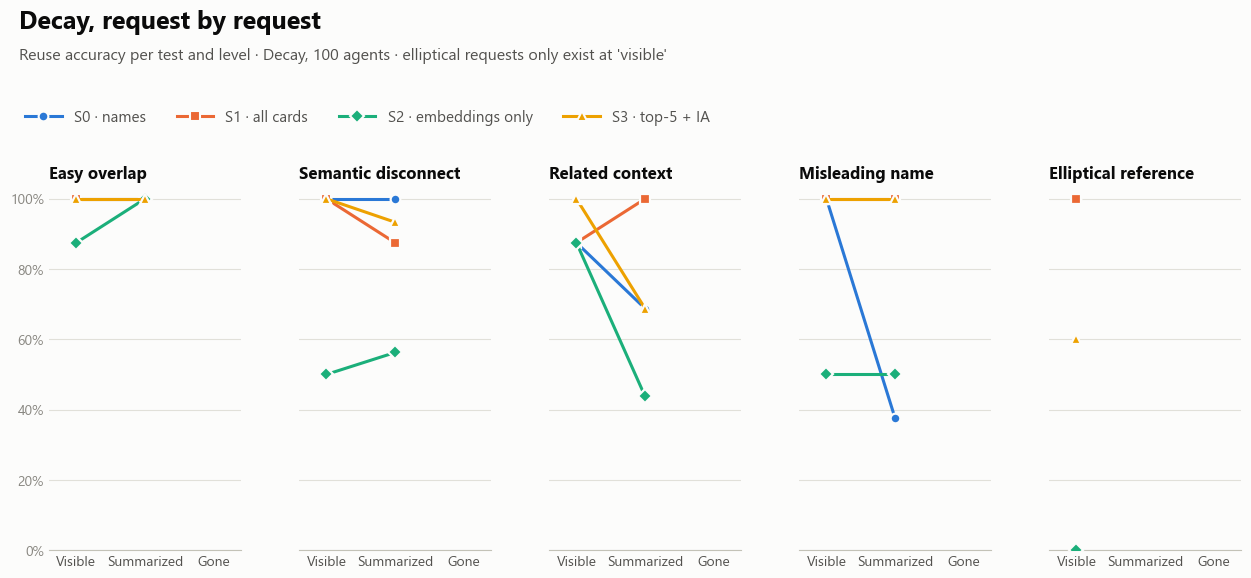

In [13]:
decay_by_test = summarize(decay[decay["is_reuse"]], ["strategy", "test", "level"])
decay_by_test["x"] = decay_by_test["level"].map(level_positions)
decay_tests = [t for t in REUSE_TESTS if t in set(decay_by_test["test"])]
fig, axes = new_figure("Decay, request by request",
                       "Reuse accuracy per test and level · Decay, 100 agents · elliptical requests only exist at 'visible'",
                       nrows=1, ncols=len(decay_tests), size=(15, 6.4), sharey=True, top=0.68)
for ax, test in zip(axes.flat, decay_tests):
    ax.set_title(TEST_NAMES[test])
    percent_axis(ax, values=decay_by_test["reuse_accuracy"])
    strategy_lines(ax, decay_by_test[decay_by_test["test"] == test], "x", "reuse_accuracy", STRATEGIES, end_labels=False)
    present = sorted(decay_by_test[decay_by_test["test"] == test]["x"].unique())
    ax.set_xticks(range(len(LEVELS)))
    ax.set_xticklabels([level.capitalize() for level in LEVELS], color=T["ink2"])
    ax.set_xlim(-0.4, len(LEVELS) - 0.6)
strategy_legend(fig, STRATEGIES, y=0.83)
finish(fig, "09_decay_by_test")

---
## 3. How each strategy fails

Accuracy alone hides *how* a strategy fails. Creating an unnecessary agent loses context;
reusing the wrong one writes into another thread's history, which is worse.

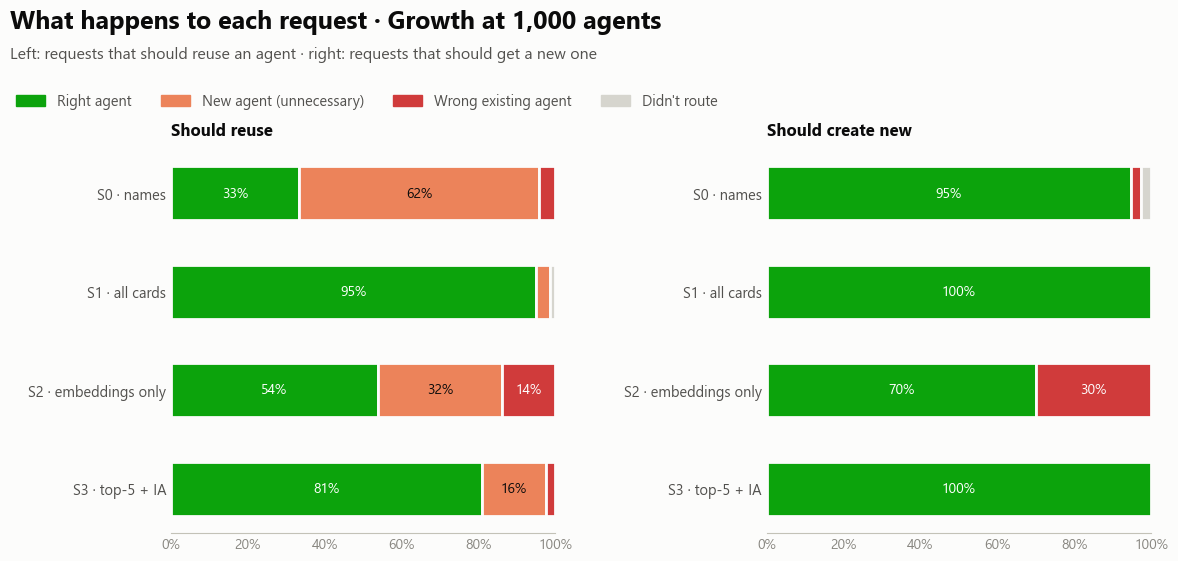

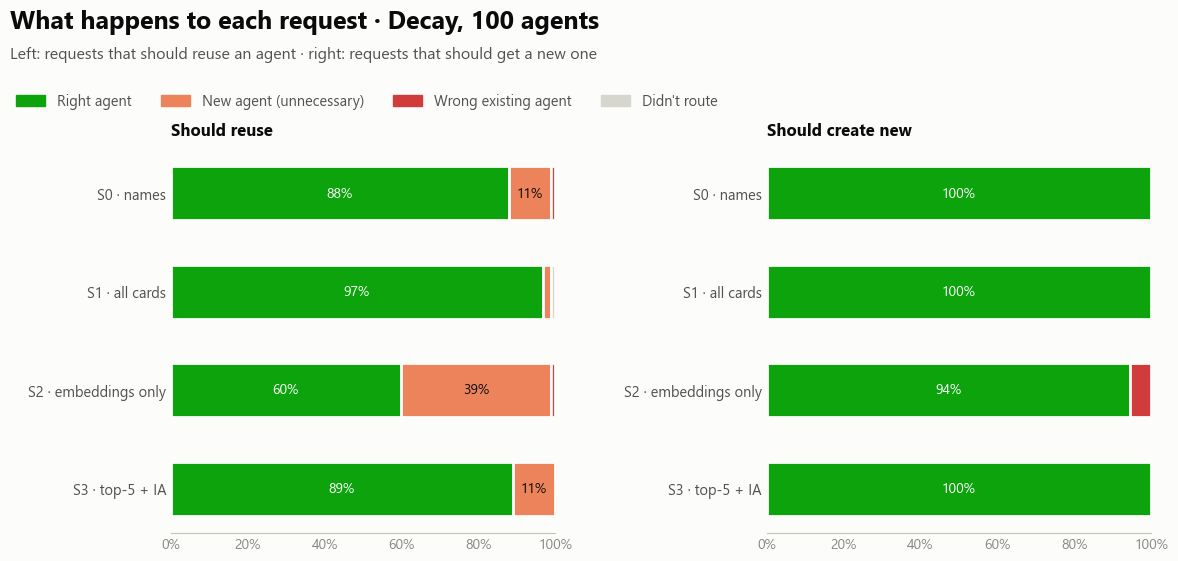

In [14]:
OUTCOMES_REUSE = [("reuse_correct", "Right agent", T["good"]), ("created", "New agent (unnecessary)", T["serious"]),
                  ("reuse_wrong", "Wrong existing agent", T["critical"]), ("no_dispatch", "Didn't route", T["neutral"])]
OUTCOMES_CREATE = [("created", "New agent (right)", T["good"]), ("reuse_wrong", "Existing agent (wrong)", T["critical"]),
                   ("no_dispatch", "Didn't route", T["neutral"])]


def outcome_bars(ax, frame, outcomes, title):
    ax.set_title(title)
    strategies = [s for s in STRATEGIES if s in set(frame["strategy"])][::-1]
    for row, s in enumerate(strategies):
        sub = frame[(frame["strategy"] == s) & ~frame["outcome"].isin(["error", "asked_user"])]
        left = 0.0
        for outcome, _, colour in outcomes:
            share = (sub["outcome"] == outcome).mean() if len(sub) else 0
            if share > 0:
                ax.barh(row, share, left=left, height=0.55, color=colour, edgecolor=T["surface"], linewidth=2)
                if share >= 0.09:
                    ax.text(left + share / 2, row, f"{share:.0%}", ha="center", va="center", fontsize=10,
                            color=ink_for(colour))
            left += share
    ax.set_yticks(range(len(strategies)))
    ax.set_yticklabels([NAME[s] for s in strategies], color=T["ink2"], fontsize=10.5)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(False)


largest = max(SIZES)
fig, axes = new_figure(f"What happens to each request · Growth at {largest:,} agents",
                       "Left: requests that should reuse an agent · right: requests that should get a new one",
                       nrows=1, ncols=2, size=(14, 6.2), top=0.74)
outcome_bars(axes[0, 0], growth[(growth["size"] == largest) & growth["is_reuse"]], OUTCOMES_REUSE, "Should reuse")
outcome_bars(axes[0, 1], growth[(growth["size"] == largest) & ~growth["is_reuse"]], OUTCOMES_CREATE, "Should create new")
handles = [Patch(color=c, label=l) for _, l, c in OUTCOMES_REUSE]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.05, 0.85), ncol=4, fontsize=10.5, labelcolor=T["ink2"])
fig.subplots_adjust(left=0.17, wspace=0.55)
finish(fig, "10_outcomes_growth_largest")

fig, axes = new_figure("What happens to each request · Decay, 100 agents",
                       "Left: requests that should reuse an agent · right: requests that should get a new one",
                       nrows=1, ncols=2, size=(14, 6.2), top=0.74)
outcome_bars(axes[0, 0], decay[decay["is_reuse"]], OUTCOMES_REUSE, "Should reuse")
outcome_bars(axes[0, 1], decay[~decay["is_reuse"]], OUTCOMES_CREATE, "Should create new")
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.05, 0.85), ncol=4, fontsize=10.5, labelcolor=T["ink2"])
fig.subplots_adjust(left=0.17, wspace=0.55)
finish(fig, "11_outcomes_decay")

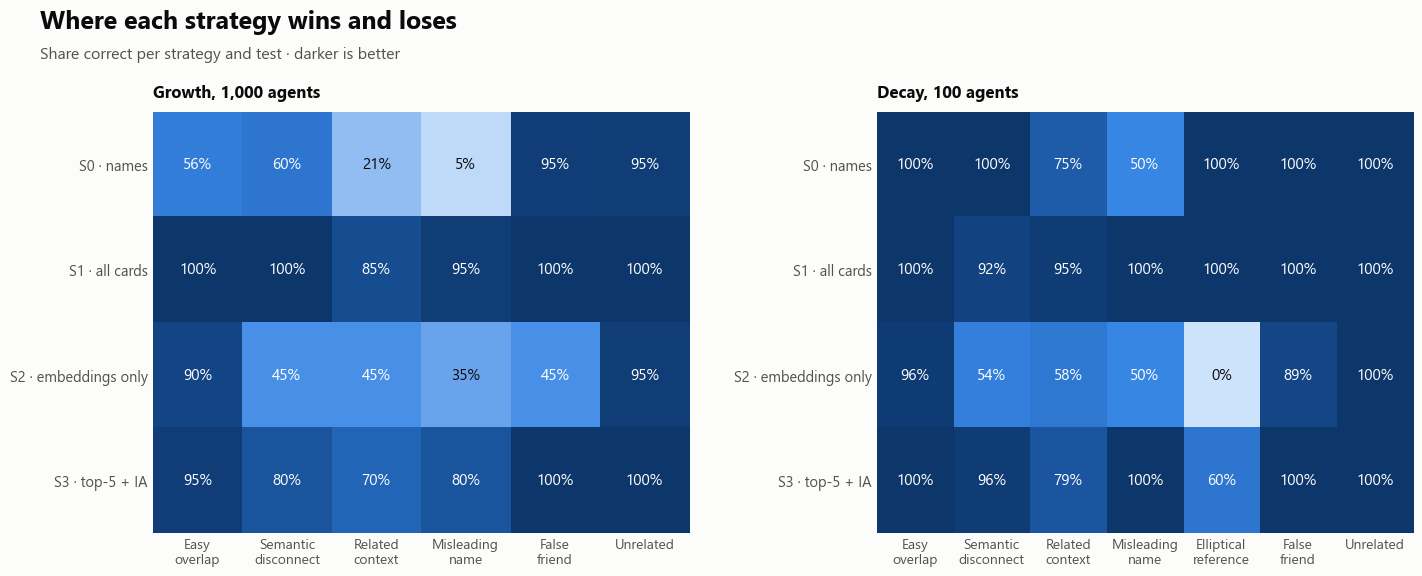

In [15]:
# Heatmap: share correct for every strategy × test, one panel per world.
cmap = LinearSegmentedColormap.from_list("seq", T["sequential"])


def heatmap(ax, frame, title):
    table = summarize(frame, ["strategy", "test"])
    table["correct"] = np.where(table["test"].isin(REUSE_TESTS), table["reuse_accuracy"], table["create_accuracy"])
    tests = [t for t in TEST_ORDER if t in set(table["test"])]
    grid = table.pivot(index="strategy", columns="test", values="correct").reindex(index=STRATEGIES, columns=tests)
    ax.imshow(grid.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            value = grid.values[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=11, color=ink_for(cmap(value)))
    ax.set_xticks(range(len(tests)))
    ax.set_xticklabels([TEST_NAMES[t].replace(" ", "\n") for t in tests], color=T["ink2"], fontsize=10)
    ax.set_yticks(range(len(STRATEGIES)))
    ax.set_yticklabels([NAME[s] for s in STRATEGIES], color=T["ink2"], fontsize=10.5)
    ax.set_title(title)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


fig, axes = new_figure("Where each strategy wins and loses",
                       f"Share correct per strategy and test · darker is better",
                       nrows=1, ncols=2, size=(15, 6.2), top=0.8)
heatmap(axes[0, 0], growth[growth["size"] == largest], f"Growth, {largest:,} agents")
heatmap(axes[0, 1], decay, "Decay, 100 agents")
fig.subplots_adjust(left=0.13, wspace=0.35, right=0.97)
finish(fig, "12_strategy_by_test_heatmap")

---
## 4. Inside the search strategies (S2, S3)

S2 and S3 use the same embedding search. **Recall@k** is the share of reuse requests where the
right agent was in the top *k*. For S3 the IA only sees the top 5, so Recall@5 is (almost) a
ceiling: the IA can still name an agent it read about in the history.

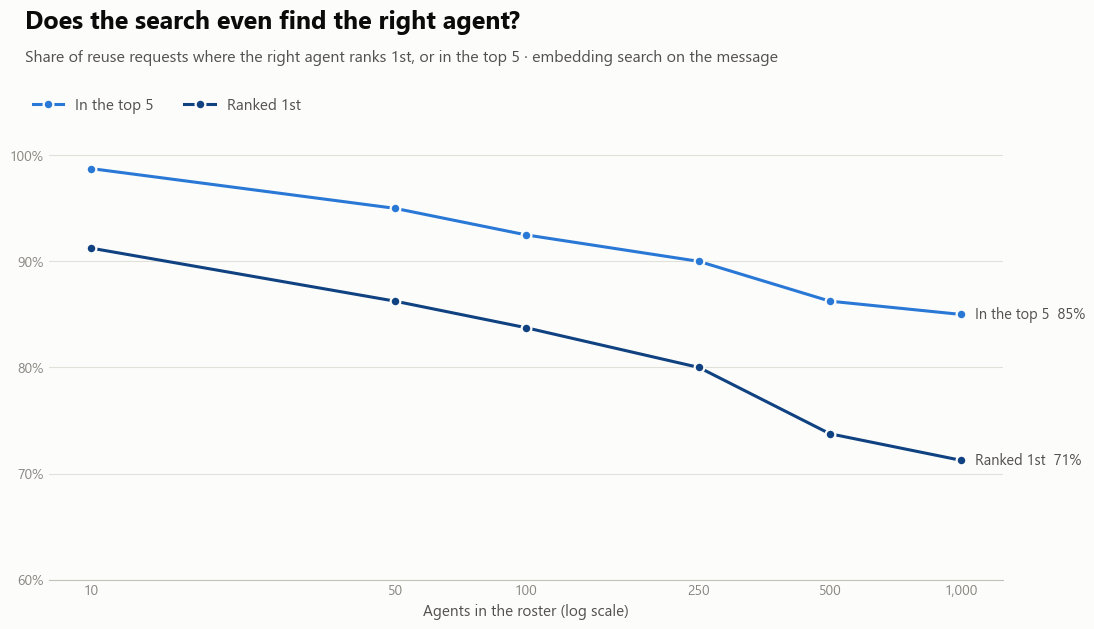

In [16]:
search = growth[(growth["strategy"] == "S3") & growth["is_reuse"]]
recall = search.groupby("size")["gold_rank"].agg(
    recall_at_1=lambda r: (r == 1).mean(), recall_at_5=lambda r: (r <= 5).mean()).reset_index()
fig, axes = new_figure("Does the search even find the right agent?",
                       "Share of reuse requests where the right agent ranks 1st, or in the top 5 · embedding search on the message")
ax = axes[0, 0]
percent_axis(ax, values=list(recall["recall_at_1"]) + list(recall["recall_at_5"]))
agents_axis(ax)
for column, label, colour in [("recall_at_5", "In the top 5", T["ordinal"][1]), ("recall_at_1", "Ranked 1st", T["ordinal"][2])]:
    ax.plot(recall["size"], recall[column], color=colour, lw=2.2, marker="o", ms=7, mec=T["surface"], mew=1.6, label=label)
    ax.annotate(f"{label}  {recall[column].iloc[-1]:.0%}", (recall["size"].iloc[-1], recall[column].iloc[-1]),
                xytext=(10, 0), textcoords="offset points", va="center", fontsize=10.5, color=T["ink2"],
                annotation_clip=False)
fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.855), ncol=2, fontsize=11, labelcolor=T["ink2"])
finish(fig, "13_search_recall")

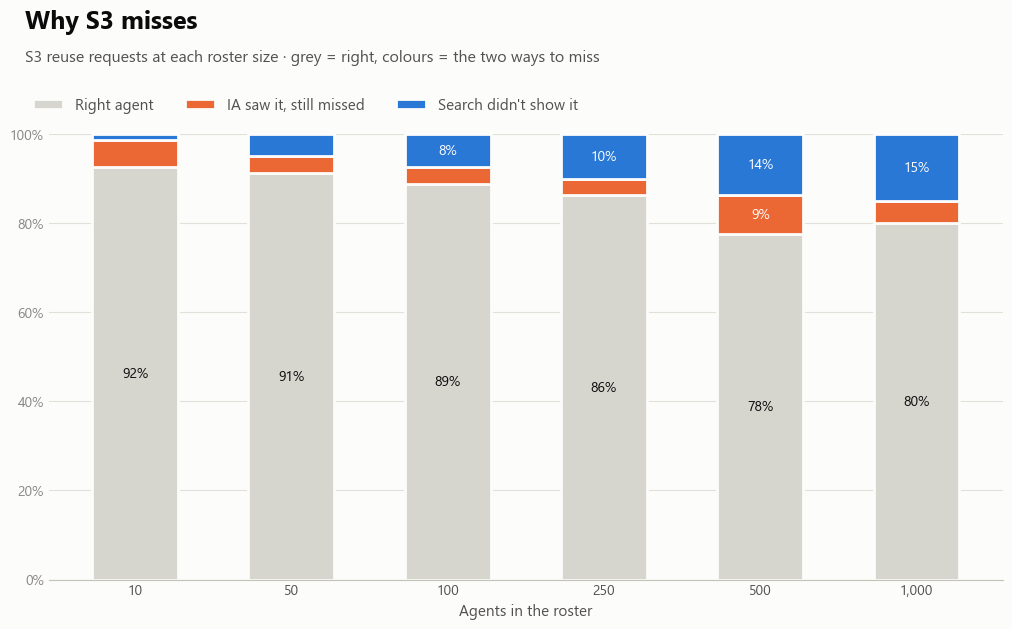

In [17]:
# Splitting S3's misses: did the search lose the agent, or did the IA see it and still miss?
rows = []
for size, group in search.groupby("size"):
    total = len(group)
    right = (group["outcome"] == "reuse_correct")
    shown = group["gold_rank"] <= 5
    rows.append({"size": size, "Right agent": right.mean(),
                 "IA saw it, still missed": (~right & shown).mean(),
                 "Search didn't show it": (~right & ~shown).mean()})
split = pd.DataFrame(rows)
parts = [("Right agent", T["neutral"]), ("IA saw it, still missed", T["series"][1]), ("Search didn't show it", T["series"][0])]
fig, axes = new_figure("Why S3 misses",
                       "S3 reuse requests at each roster size · grey = right, colours = the two ways to miss")
ax = axes[0, 0]
positions = np.arange(len(split))
bottom = np.zeros(len(split))
for label, colour in parts:
    values = split[label].values
    ax.bar(positions, values, bottom=bottom, width=0.55, color=colour, edgecolor=T["surface"], linewidth=2, label=label)
    for x, (b, v) in enumerate(zip(bottom, values)):
        if v >= 0.07:
            ax.text(x, b + v / 2, f"{v:.0%}", ha="center", va="center", fontsize=10, color=ink_for(colour))
    bottom += values
ax.set_xticks(positions)
ax.set_xticklabels([f"{s:,}" for s in split["size"]], color=T["ink2"])
ax.set_xlabel("Agents in the roster")
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 1.0)
fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.855), ncol=3, fontsize=11, labelcolor=T["ink2"])
finish(fig, "14_s3_miss_split")

C:\Users\sarin\Desktop\OpenPoke\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


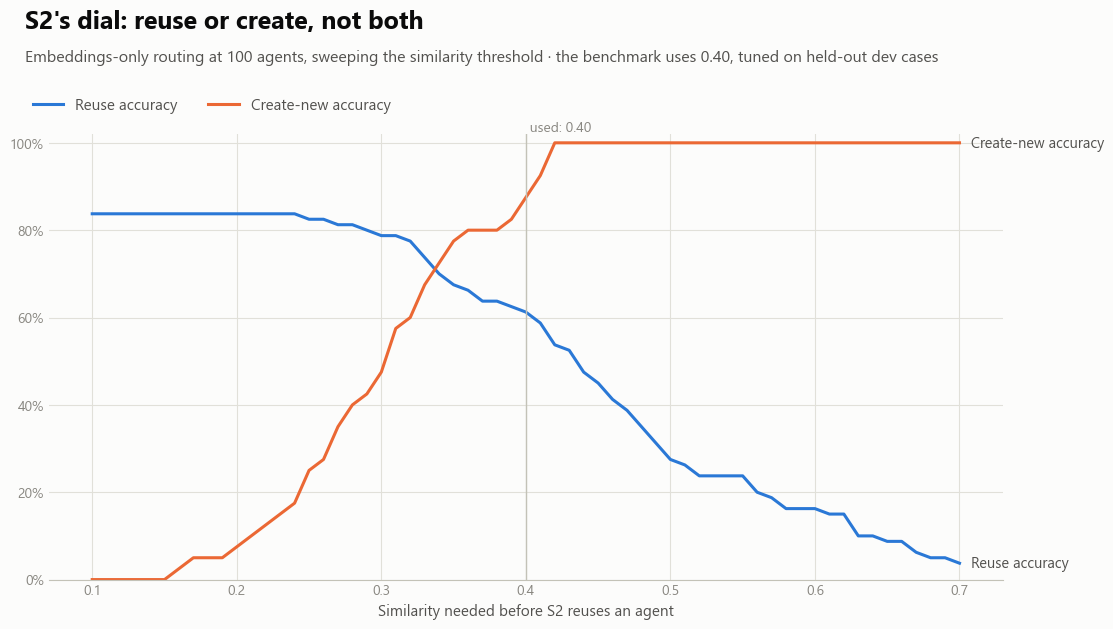

In [18]:
# S2's threshold, swept. Recomputed locally from the benchmark's own cases and code (free, no API).
sys.path.insert(0, str(REPO_DIR))
from evals import strategies as strategy_code
from evals.dataset import load_cases, roster_for, BUILT_DIR, load_json
from evals.harness import grade

tuned = load_json(BUILT_DIR / "s2_threshold.json")["threshold"]
sweep_size = 100 if 100 in SIZES else SIZES[len(SIZES) // 2]
ranked_cases = []
for case in load_cases("growth"):
    roster = roster_for(case, sweep_size)
    ranked_cases.append((case, strategy_code.rank_agents(roster, case["message"]), {a["name"] for a in roster}))

sweep = []
for threshold in np.arange(0.10, 0.71, 0.01):
    reuse_right, create_right, reuse_n, create_n = 0, 0, 0, 0
    for case, ranked, names in ranked_cases:
        picked = strategy_code.pick_nearest(ranked, threshold)
        outcome = grade([picked] if picked else ["(new agent)"], case["answer"], names)
        if case["answer"]:
            reuse_n += 1
            reuse_right += outcome == "reuse_correct"
        else:
            create_n += 1
            create_right += outcome == "created"
    sweep.append({"threshold": threshold, "reuse": reuse_right / reuse_n, "create": create_right / create_n})
sweep = pd.DataFrame(sweep)

fig, axes = new_figure("S2's dial: reuse or create, not both",
                       f"Embeddings-only routing at {sweep_size} agents, sweeping the similarity threshold · "
                       f"the benchmark uses {tuned:.2f}, tuned on held-out dev cases")
ax = axes[0, 0]
percent_axis(ax)
for column, label, colour in [("reuse", "Reuse accuracy", T["series"][0]), ("create", "Create-new accuracy", T["series"][1])]:
    ax.plot(sweep["threshold"], sweep[column], color=colour, lw=2.2, label=label)
    ax.annotate(label, (sweep["threshold"].iloc[-1], sweep[column].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=10.5, color=T["ink2"], annotation_clip=False)
ax.axvline(tuned, color=T["axis"], lw=1)
ax.text(tuned, 1.02, f" used: {tuned:.2f}", color=T["muted"], fontsize=10, va="bottom")
ax.set_xlabel("Similarity needed before S2 reuses an agent")
ax.grid(True, axis="both")
fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.855), ncol=2, fontsize=11, labelcolor=T["ink2"])
finish(fig, "15_s2_threshold_sweep")

---
## 5. Order sensitivity

The same 30 requests at 100 agents, each run three times with the agent list shuffled. A
change of outcome means position in the list, not the content, decided the answer.

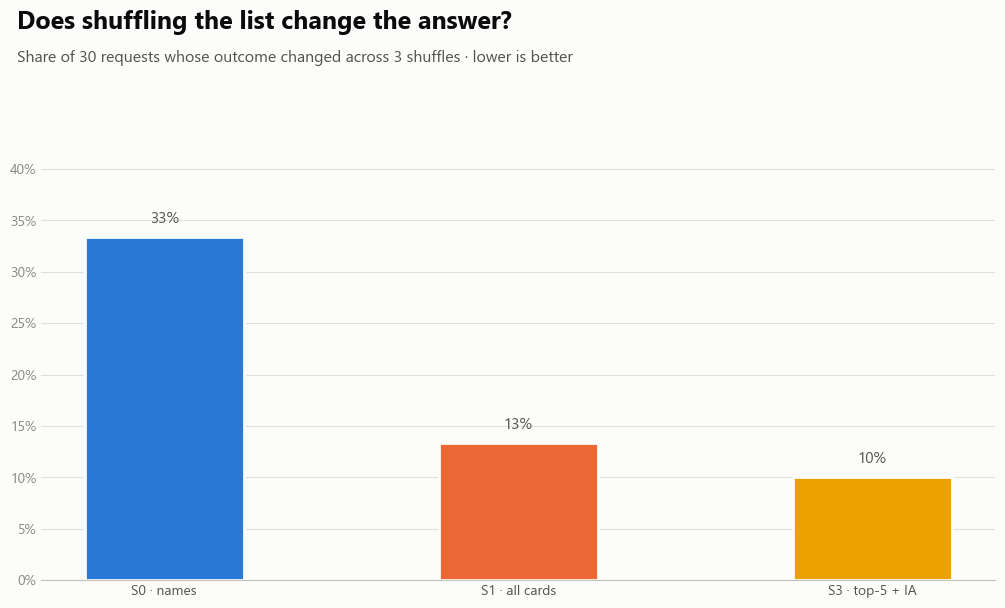

In [19]:
if order is None:
    print("No order-check results yet: run `python -m evals.run_benchmark --order-check`.")
else:
    changed = (order.groupby(["strategy", "case_id"])["outcome"].nunique() > 1).groupby("strategy").mean()
    strategies = [s for s in STRATEGIES if s in changed.index]
    fig, axes = new_figure("Does shuffling the list change the answer?",
                           f"Share of {order['case_id'].nunique()} requests whose outcome changed across 3 shuffles · lower is better")
    ax = axes[0, 0]
    positions = np.arange(len(strategies))
    ax.bar(positions, [changed[s] for s in strategies], width=0.45, color=[COLOR[s] for s in strategies],
           edgecolor=T["surface"], linewidth=2)
    for x, s in enumerate(strategies):
        ax.text(x, changed[s] + 0.01, f"{changed[s]:.0%}", ha="center", va="bottom", fontsize=11, color=T["ink2"])
    ax.set_xticks(positions)
    ax.set_xticklabels([NAME[s] for s in strategies], color=T["ink2"])
    ax.set_ylim(0, max(0.2, float(changed.max()) * 1.3))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    finish(fig, "16_order_sensitivity")

---
## 6. Summary table

Everything above in one table (Growth pooled over sizes, and Decay), for copying into slides.

In [20]:
summary = pd.concat([
    summarize(growth, ["strategy"]).assign(world="Growth (all sizes)"),
    summarize(growth[growth["size"] == largest], ["strategy"]).assign(world=f"Growth, {largest:,} agents"),
    summarize(decay, ["strategy"]).assign(world="Decay, 100 agents"),
])
columns = ["world", "strategy", "reuse_accuracy", "create_accuracy", "wrong_reuse_rate", "unnecessary_new_rate",
           "no_dispatch_rate", "asked_rate", "prompt_tokens_per_call", "cost_per_1k_requests"]
summary = summary[columns].reset_index(drop=True)
summary.style.format({c: "{:.0%}" for c in columns[2:8]} | {"prompt_tokens_per_call": "{:,.0f}", "cost_per_1k_requests": "${:.2f}"}, na_rep="–").hide(axis="index")

world,strategy,reuse_accuracy,create_accuracy,wrong_reuse_rate,unnecessary_new_rate,no_dispatch_rate,asked_rate,prompt_tokens_per_call,cost_per_1k_requests
Growth (all sizes),S0,42%,93%,6%,51%,1%,5%,"7,015",$1.67
Growth (all sizes),S1,96%,99%,0%,3%,1%,1%,"19,923",$4.30
Growth (all sizes),S2,59%,84%,10%,35%,0%,0%,–,$0.00
Growth (all sizes),S3,88%,99%,1%,10%,1%,2%,"3,909",$1.04
"Growth, 1,000 agents",S0,33%,95%,4%,62%,1%,8%,"14,546",$3.21
"Growth, 1,000 agents",S1,95%,100%,0%,4%,1%,2%,"55,168",$11.68
"Growth, 1,000 agents",S2,54%,70%,19%,32%,0%,0%,–,$0.00
"Growth, 1,000 agents",S3,81%,100%,2%,16%,0%,1%,"3,907",$1.02
"Decay, 100 agents",S0,88%,100%,1%,11%,0%,1%,"17,505",$3.86
"Decay, 100 agents",S1,97%,100%,0%,2%,1%,2%,"22,335",$4.81


---
## 7. What I learned

Written after run `20260923-063434` (3,320 requests, $6.48) and order check `20260923-063559`.
The numbers in the code cells are recomputed on every run; the text is not, so re-read it
against the figures if you run again.

### The short version

| Strategy | At 10 agents | At 1,000 agents | Cost per 1,000 requests at 1,000 agents | In one line |
|---|---|---|---|---|
| **S0** names (today) | 50% | 33% | $3.21 | A name only says what the agent's first job was |
| **S1** all cards | 99% | 95% | $11.68 | Best, and never reuses the wrong agent, but the prompt grows with every agent |
| **S2** embeddings only | 62% | 54% | free | Reuses the wrong agent more and more as the list grows |
| **S3** top-5 cards + IA | 95% | 81% | $1.02 | Nearly as good as S1 while the search finds the agent; cheapest of all |

(Reuse accuracy in Growth: the share of "should reuse" requests sent to the right agent.)

**If you remember one thing:** the IA needs to know *what an agent knows*, not just what it's
called. Cards give it that. Showing all cards (S1) is the most accurate; showing the 5 best
cards (S3) is almost as good and far cheaper, and its misses are almost all search misses,
so better search is the way to close the gap.

### Insight 1 · A name only describes the agent's first job

The IA names an agent when it creates it, and the name never changes. "Speech Draft" was made
for a best man speech; later the same agent handled the rehearsal dinner seating with Chloe.
When the request is about that later job, a list of names gives the IA nothing to go on.

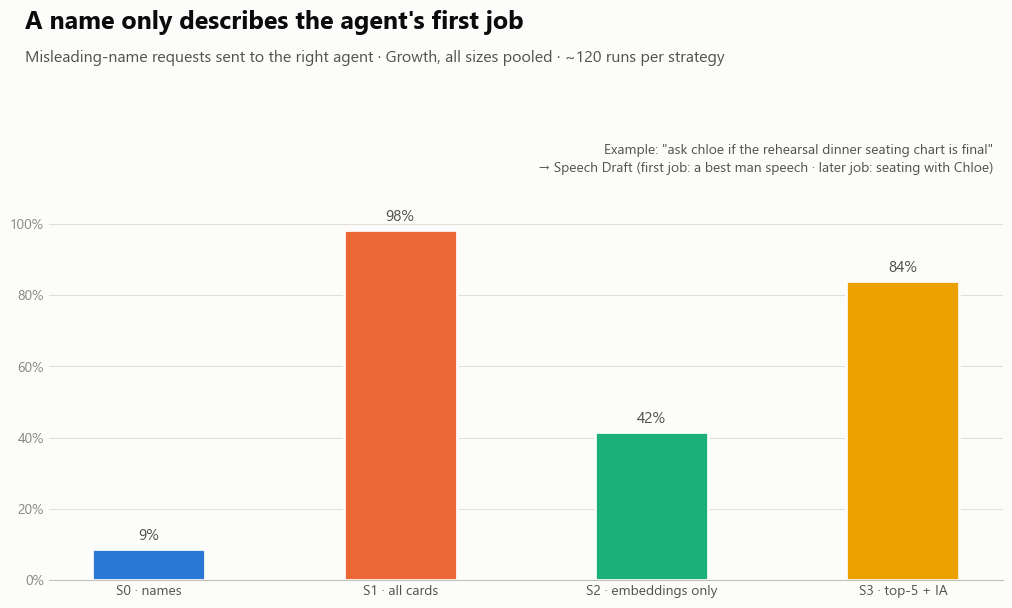

In [21]:
ia_strategies = [s for s in STRATEGIES if s != "S2"]
misleading = growth[(growth["test"] == "misleading_name") & ~growth["outcome"].isin(["error", "asked_user"])]
right_share = misleading.groupby("strategy")["correct"].mean().reindex(STRATEGIES)
runs_per_strategy = misleading.groupby("strategy").size().max()

fig, axes = new_figure("A name only describes the agent's first job",
                       f"Misleading-name requests sent to the right agent · Growth, all sizes pooled · ~{runs_per_strategy} runs per strategy")
ax = axes[0, 0]
positions = np.arange(len(STRATEGIES))
ax.bar(positions, right_share.values, width=0.45, color=[COLOR[s] for s in STRATEGIES], edgecolor=T["surface"], linewidth=2)
for x, s in enumerate(STRATEGIES):
    ax.text(x, right_share[s] + 0.015, f"{right_share[s]:.0%}", ha="center", va="bottom", fontsize=11, color=T["ink2"])
ax.set_xticks(positions)
ax.set_xticklabels([NAME[s] for s in STRATEGIES], color=T["ink2"])
ax.set_ylim(0, 1.25)
ax.yaxis.set_major_locator(FixedLocator([0, 0.2, 0.4, 0.6, 0.8, 1.0]))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.text(0.99, 0.98, 'Example: "ask chloe if the rehearsal dinner seating chart is final"\n'
        "→ Speech Draft (first job: a best man speech · later job: seating with Chloe)",
        transform=ax.transAxes, ha="right", va="top", fontsize=10, color=T["ink2"], linespacing=1.5)
finish(fig, "17_insight_misleading_name")

S0 gets about 1 in 12 right. Every strategy that reads cards does far better, because the card
records the later work ("Also handling rehearsal dinner seating with Chloe"). S3 is a little
below S1 here because the search sometimes ranks the right card 6th or lower.

### Insight 2 · The summary keeps the facts but drops the agent's name

In Decay, old conversation is folded into a summary. The summary is good at keeping facts
("Maya's birthday; gift shortlist: Claymates pottery voucher $85 or Osprey daypack $95"), but
it usually leaves out *which agent* did the work. Only 5 of the 16 summarized target agents
still have their name in the summary. Without the name, S0 has to guess which agent the facts
belong to.

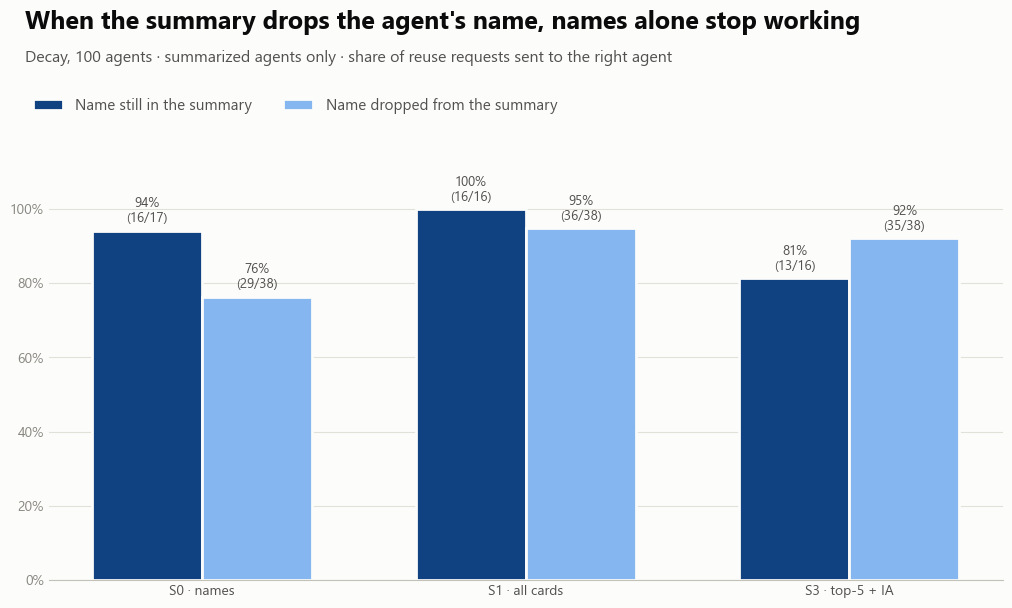

In [22]:
import re

decay_history = (EVALS_DIR / "data" / "built" / "decay_history.txt").read_text(encoding="utf-8")
summary_text = re.search(r"<conversation_summary>(.*?)</conversation_summary>", decay_history, re.S).group(1).lower()
summarized = decay[(decay["level"] == "summarized") & decay["is_reuse"] & (decay["test"] != "elliptical_reference")
                   & ~decay["outcome"].isin(["error", "asked_user"])].copy()
summarized["name_kept"] = summarized["answer"].str.lower().apply(lambda name: name in summary_text)

fig, axes = new_figure("When the summary drops the agent's name, names alone stop working",
                       "Decay, 100 agents · summarized agents only · share of reuse requests sent to the right agent")
ax = axes[0, 0]
groups = [(True, "Name still in the summary", T["ordinal"][2]), (False, "Name dropped from the summary", T["ordinal"][0])]
width = 0.34
for offset, (kept, label, colour) in zip([-width / 2, width / 2], groups):
    for x, s in enumerate(ia_strategies):
        sub = summarized[(summarized["strategy"] == s) & (summarized["name_kept"] == kept)]
        value = sub["correct"].mean()
        ax.bar(x + offset, value, width=width, color=colour, edgecolor=T["surface"], linewidth=2,
               label=label if x == 0 else None)
        ax.text(x + offset, value + 0.015, f"{value:.0%}\n({sub['correct'].sum()}/{len(sub)})", ha="center", va="bottom",
                fontsize=9.5, color=T["ink2"])
ax.set_xticks(range(len(ia_strategies)))
ax.set_xticklabels([NAME[s] for s in ia_strategies], color=T["ink2"])
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_locator(FixedLocator([0, 0.2, 0.4, 0.6, 0.8, 1.0]))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.855), ncol=2, fontsize=11, labelcolor=T["ink2"])
finish(fig, "18_insight_summary_drops_names")

With the name kept, S0 is nearly perfect; with it dropped, S0 falls to about 3 in 4. S1 barely
notices, because the card carries the name and the facts together. This is exactly the problem
cards were meant to solve.

S3 looks backwards here (worse when the name is kept), but don't read much into it: that group
is only 16 requests, so it's 3 misses, and S3's misses come from its search, which looks at the
message and the cards, never at the summary.

### Insight 3 · Where wrong reuses land

Reusing the *wrong* agent is the worst mistake: the new instructions end up in another thread.
This splits every wrong reuse in Growth by what kind of agent got picked:

- **look-alike:** the agent written to share a name or word with the request (e.g. "Tutoring with Alex" for a request about Alex Chen);
- **filler:** one of the 1,000 generated agents;
- **anchor:** the gym, groceries or dentist agents from the chat.

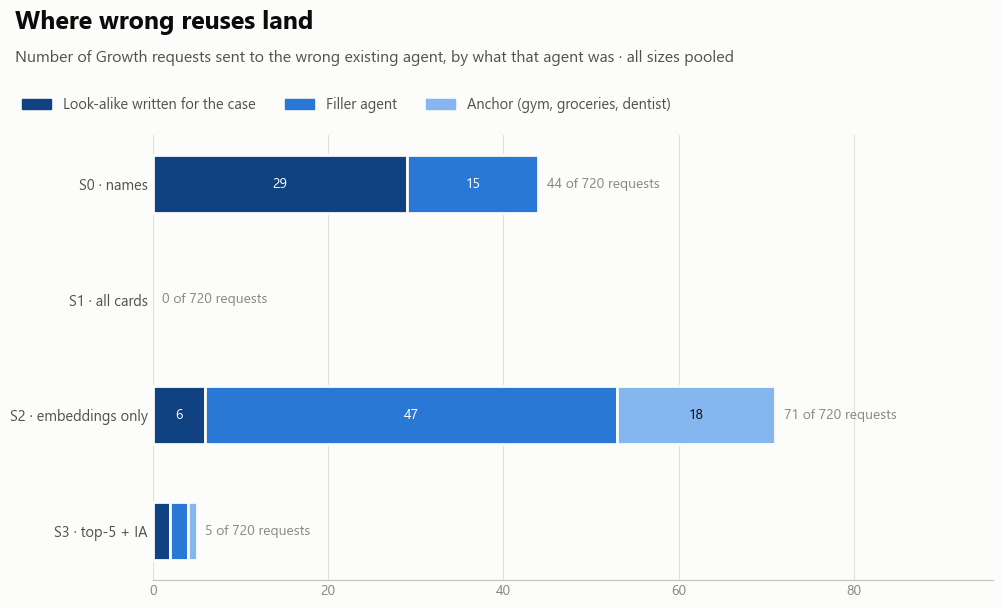

In [23]:
sys.path.insert(0, str(REPO_DIR))
from evals.dataset import load_cases, load_fillers

filler_names = {agent["name"] for agent in load_fillers()}
case_agents = {case["id"]: set(case["roster_agents"]) for case in load_cases("growth")}


def wrong_target(row):
    # What kind of existing agent the IA wrongly sent the request to.
    for name in row["dispatched"]:
        if name == row["answer"]:
            continue
        if name in case_agents[row["case_id"]]:
            return "Look-alike written for the case"
        if name in filler_names:
            return "Filler agent"
    return "Anchor (gym, groceries, dentist)"


wrong = growth[growth["outcome"] == "reuse_wrong"].copy()
wrong["target"] = wrong.apply(wrong_target, axis=1)
counts = wrong.groupby(["strategy", "target"]).size().unstack(fill_value=0).reindex(STRATEGIES, fill_value=0)
kinds = [("Look-alike written for the case", T["ordinal"][2]), ("Filler agent", T["ordinal"][1]),
         ("Anchor (gym, groceries, dentist)", T["ordinal"][0])]
runs = growth.groupby("strategy").size()

fig, axes = new_figure("Where wrong reuses land",
                       "Number of Growth requests sent to the wrong existing agent, by what that agent was · all sizes pooled")
ax = axes[0, 0]
rows_ = STRATEGIES[::-1]
for y, s in enumerate(rows_):
    left = 0
    for kind, colour in kinds:
        value = counts.loc[s, kind] if kind in counts.columns else 0
        if value:
            ax.barh(y, value, left=left, height=0.5, color=colour, edgecolor=T["surface"], linewidth=2)
            if value >= 4:
                ax.text(left + value / 2, y, str(value), ha="center", va="center", fontsize=10, color=ink_for(colour))
        left += value
    ax.text(left + 1, y, f"{left} of {runs[s]:,} requests", va="center", fontsize=10, color=T["muted"])
ax.set_yticks(range(len(rows_)))
ax.set_yticklabels([NAME[s] for s in rows_], color=T["ink2"], fontsize=10.5)
ax.set_xlim(0, counts.sum(axis=1).max() * 1.35)
ax.grid(True, axis="x")
ax.grid(False, axis="y")
fig.legend(handles=[Patch(color=c, label=k) for k, c in kinds], loc="upper left", bbox_to_anchor=(0.05, 0.855),
           ncol=3, fontsize=10.5, labelcolor=T["ink2"])
fig.subplots_adjust(left=0.17)
finish(fig, "19_insight_wrong_reuse_targets")

- **S2 mostly lands on fillers.** Fillers are written to look like real agents (other invoices,
  other emails), and a similarity score can't tell "an invoice" from "*this* invoice".
- **S0 mostly lands on look-alikes:** "send grace liu my gst number" → "Movie Night with Grace",
  because the only Grace it can see is in a name.
- **S1 never reuses the wrong agent, and S3 almost never.** Once the IA can read the card, it
  sees that Grace Liu isn't the movie-night Grace.

### Insight 4 · S3's misses are search misses

At 1,000 agents, S3 missed 15 of 79 reuse requests, and in 12 of those the right agent wasn't
in the top 5 at all (figure 14 shows this at every size). When the IA does see the right card,
it almost always picks it. So **S3 is only as good as its search**. Ways to improve the search
are listed at the end.

### Insight 5 · What the IA does when it doesn't route correctly

Asking the user first is left out of the scores. This shows how often it happens, and what the
remaining misses were.

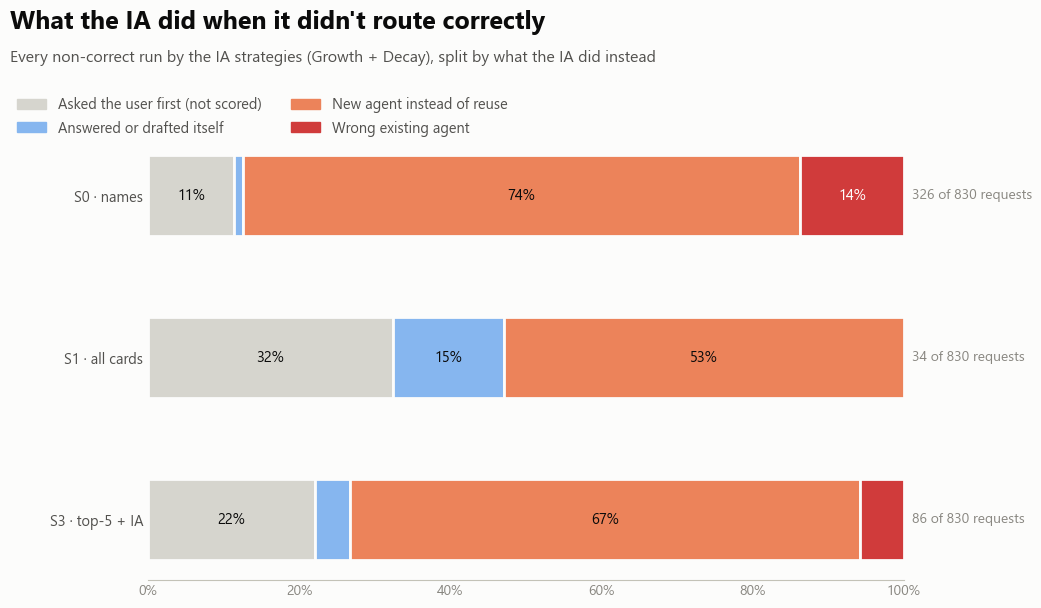

In [24]:
def miss_kind(row):
    if row["outcome"] == "asked_user":
        return "Asked the user first (not scored)"
    if row["outcome"] == "no_dispatch":
        return "Answered or drafted itself"
    if row["outcome"] == "reuse_wrong":
        return "Wrong existing agent"
    return "New agent instead of reuse"


MISS_KINDS = [("Asked the user first (not scored)", T["neutral"]), ("Answered or drafted itself", T["ordinal"][0]),
              ("New agent instead of reuse", T["serious"]), ("Wrong existing agent", T["critical"])]
misses = main[(~main["correct"]) & (main["outcome"] != "error") & main["strategy"].isin(ia_strategies)].copy()
misses["kind"] = misses.apply(miss_kind, axis=1)
share = misses.groupby("strategy")["kind"].value_counts(normalize=True).unstack(fill_value=0)
runs = main[main["strategy"].isin(ia_strategies)].groupby("strategy").size()

fig, axes = new_figure("What the IA did when it didn't route correctly",
                       "Every non-correct run by the IA strategies (Growth + Decay), split by what the IA did instead")
ax = axes[0, 0]
strategies = ia_strategies[::-1]
for row, s in enumerate(strategies):
    left = 0.0
    for kind, colour in MISS_KINDS:
        value = share.loc[s, kind] if kind in share.columns else 0
        if value > 0:
            ax.barh(row, value, left=left, height=0.5, color=colour, edgecolor=T["surface"], linewidth=2)
            if value >= 0.08:
                ax.text(left + value / 2, row, f"{value:.0%}", ha="center", va="center", fontsize=10.5, color=ink_for(colour))
        left += value
    n_miss = (misses["strategy"] == s).sum()
    ax.text(1.01, row, f"{n_miss} of {runs[s]:,} requests", va="center", fontsize=10, color=T["muted"])
ax.set_yticks(range(len(strategies)))
ax.set_yticklabels([NAME[s] for s in strategies], color=T["ink2"], fontsize=10.5)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(False)
fig.legend(handles=[Patch(color=c, label=k) for k, c in MISS_KINDS], loc="upper left", bbox_to_anchor=(0.05, 0.855),
           ncol=2, fontsize=10.5, labelcolor=T["ink2"])
fig.subplots_adjust(left=0.17, right=0.8)
finish(fig, "20_insight_miss_kinds")

The most common miss by far is **creating a new agent when one already had the context**.
S0 also asks the user a question about 3× as often as S1 (37 vs 11 of 830 requests): when it
can't tell which agent fits, it asks instead.

### Insight 6 · A new task gets a new agent, even with the right card in view

In *related context* requests, the right agent has useful facts, but the task is new ("book a
hotel near hart house for the night of daniel's wedding" → Speech Draft knows the wedding is
Oct 25 at Hart House). The IA often creates a new agent named after the task instead. Because
this happens with names and cards alike, the fix belongs in the IA's instructions, not the
agent list.

C:\Users\sarin\AppData\Local\Temp\ipykernel_6324\3078172232.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  new_share = related.groupby("strategy").apply(lambda g: (g["outcome"] == "created").mean())


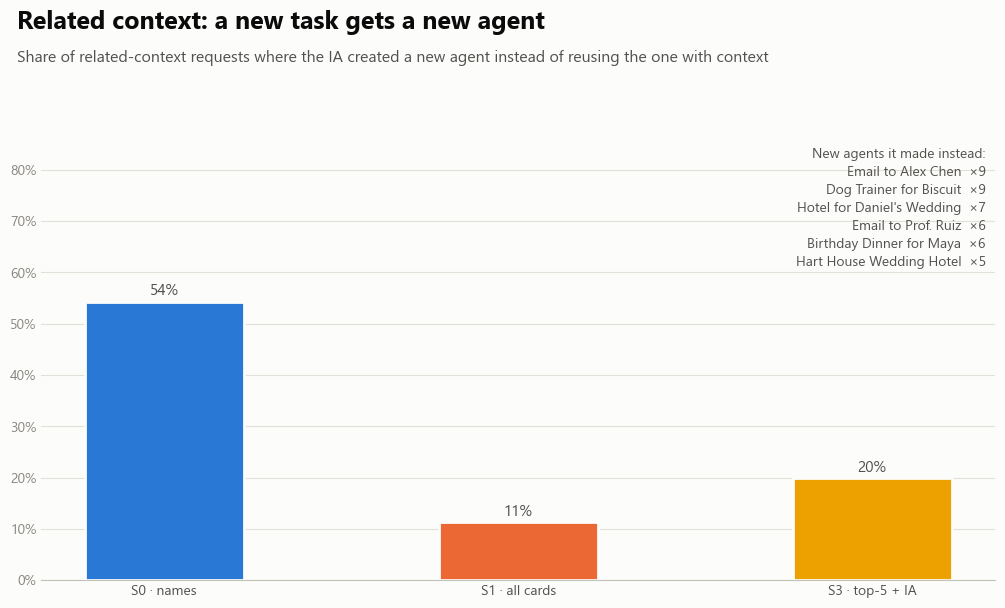

In [25]:
related = main[(main["test"] == "related_context") & main["strategy"].isin(ia_strategies)
               & ~main["outcome"].isin(["error", "asked_user"])]
new_share = related.groupby("strategy").apply(lambda g: (g["outcome"] == "created").mean())
examples = related[related["outcome"] == "created"]["dispatched"].explode().value_counts().head(6)

fig, axes = new_figure("Related context: a new task gets a new agent",
                       "Share of related-context requests where the IA created a new agent instead of reusing the one with context")
ax = axes[0, 0]
positions = np.arange(len(ia_strategies))
ax.bar(positions, [new_share.get(s, 0) for s in ia_strategies], width=0.45, color=[COLOR[s] for s in ia_strategies],
       edgecolor=T["surface"], linewidth=2)
for x, s in enumerate(ia_strategies):
    ax.text(x, new_share.get(s, 0) + 0.005, f"{new_share.get(s, 0):.0%}", ha="center", va="bottom", fontsize=11, color=T["ink2"])
ax.set_xticks(positions)
ax.set_xticklabels([NAME[s] for s in ia_strategies], color=T["ink2"])
ax.set_ylim(0, max(0.25, float(new_share.max()) * 1.6))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.text(0.99, 0.97, "New agents it made instead:\n" + "\n".join(f"{name}  ×{count}" for name, count in examples.items()),
        transform=ax.transAxes, ha="right", va="top", fontsize=10, color=T["ink2"], linespacing=1.5)
finish(fig, "21_insight_related_context_new_agents")

### Insight 7 · The requests missed most often

A request that fails for every strategy is either genuinely hard or a flaw in the dataset, so
these are worth reading by hand. Most are *related context* or *misleading name*, which fits
insights 1 and 6.

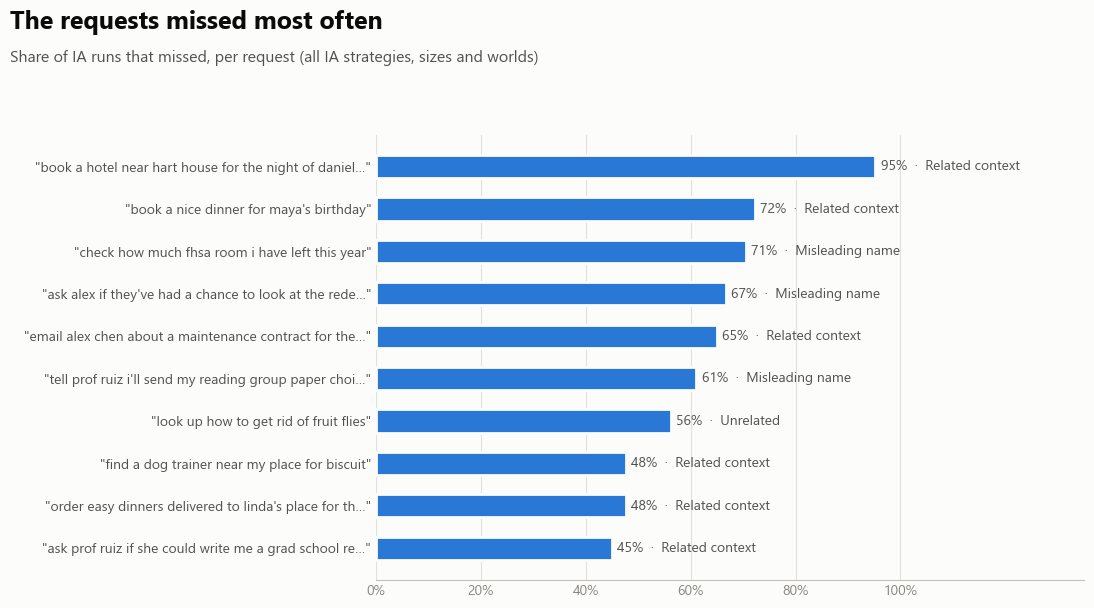

In [26]:
main["written_id"] = main["case_id"].str.split("-", n=1).str[1]
ia_runs = main[main["strategy"].isin(ia_strategies) & ~main["outcome"].isin(["error", "asked_user"])]
per_case = ia_runs.groupby("written_id").agg(runs=("correct", "size"), misses=("correct", lambda c: (~c).sum()))
per_case["miss_rate"] = per_case["misses"] / per_case["runs"]
worst = per_case.sort_values("miss_rate", ascending=False).head(10)[::-1]
written_cases = load_json(REPO_DIR / "evals" / "data" / "written" / "cases.json")
messages = {c["id"]: c["message"] for c in written_cases}
tests = {c["id"]: c["test"] for c in written_cases}

fig, axes = new_figure("The requests missed most often",
                       "Share of IA runs that missed, per request (all IA strategies, sizes and worlds)")
ax = axes[0, 0]
ax.barh(range(len(worst)), worst["miss_rate"], height=0.55, color=T["series"][0], edgecolor=T["surface"], linewidth=2)
for y, (cid, row) in enumerate(worst.iterrows()):
    ax.text(row["miss_rate"] + 0.01, y, f"{row['miss_rate']:.0%}  ·  {TEST_NAMES[tests[cid]]}", va="center",
            fontsize=10, color=T["ink2"])
ax.set_yticks(range(len(worst)))
ax.set_yticklabels([f'"{messages[cid][:52]}{"…" if len(messages[cid]) > 52 else ""}"' for cid in worst.index],
                   color=T["ink2"], fontsize=10)
ax.set_xlim(0, 1.35)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(True, axis="x")
ax.grid(False, axis="y")
fig.subplots_adjust(left=0.36, right=0.95)
finish(fig, "22_insight_worst_cases")

"look up how to get rid of fruit flies" is on the list but isn't a routing mistake: the IA
simply answered the question itself (vinegar trap) instead of starting any agent.

### Insight 8 · At 1,000 agents, S3 is the cheapest of all

S1 pays for every card on every call. But S0 isn't free either: a list of 1,000 names is about
14.5k tokens. S3's prompt holds only 5 cards, whatever the roster size.

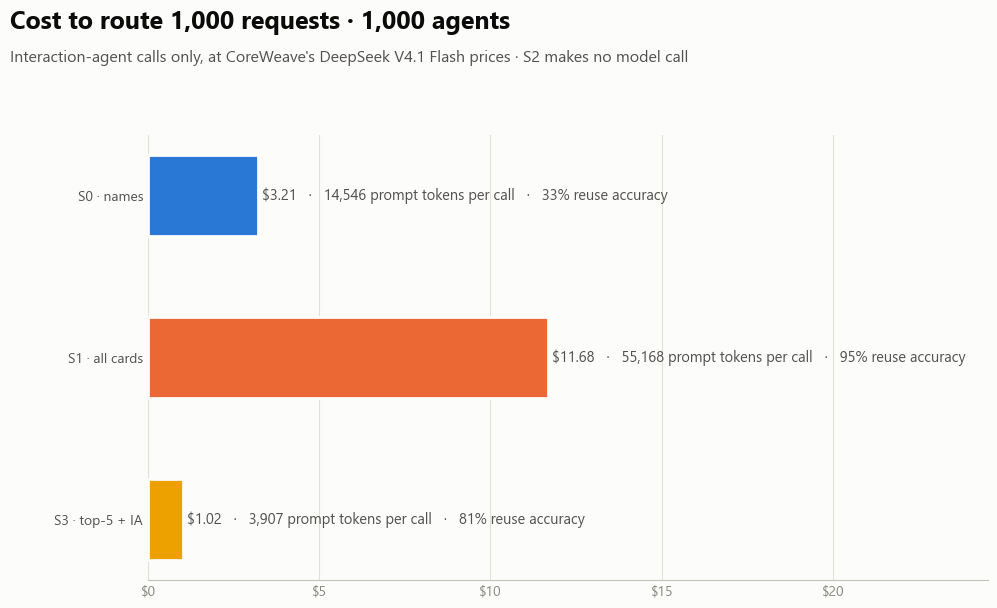

In [27]:
at_largest = growth_table[growth_table["strategy"].isin(ia_strategies) & (growth_table["size"] == largest)].set_index("strategy")
fig, axes = new_figure(f"Cost to route 1,000 requests · {largest:,} agents",
                       "Interaction-agent calls only, at CoreWeave's DeepSeek V4.1 Flash prices · S2 makes no model call")
ax = axes[0, 0]
order_ = ia_strategies
values = [at_largest.loc[s, "cost_per_1k_requests"] for s in order_]
ax.barh(range(len(order_))[::-1], values, height=0.5, color=[COLOR[s] for s in order_], edgecolor=T["surface"], linewidth=2)
for y, (s, v) in zip(range(len(order_))[::-1], zip(order_, values)):
    tokens = at_largest.loc[s, "prompt_tokens_per_call"]
    accuracy = at_largest.loc[s, "reuse_accuracy"]
    ax.text(v + max(values) * 0.01, y, f"${v:.2f}   ·   {tokens:,.0f} prompt tokens per call   ·   {accuracy:.0%} reuse accuracy",
            va="center", fontsize=10.5, color=T["ink2"])
ax.set_yticks(range(len(order_))[::-1])
ax.set_yticklabels([NAME[s] for s in order_], color=T["ink2"])
ax.set_xlim(0, max(values) * 2.1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:.0f}"))
ax.grid(True, axis="x")
ax.grid(False, axis="y")
fig.subplots_adjust(left=0.17)
finish(fig, "23_insight_cost_at_largest")

---
## 8. Surprises, things to notice, and what's next

### What surprised me

1. **S0 is weak even at 10 agents (50%).** I expected roster size to be S0's main problem.
   It does hurt (50% → 33%), but vague names hurt more: with only 10 names, the IA still can't
   tell that "Flight Booking" also holds the Kyoto ryokan options, or that "Tax Stuff" involves Grace Liu.
2. **S1 doesn't get confused by a huge prompt.** At 1,000 agents it reads ~55k tokens of cards
   and still routes 95% right with zero wrong reuse. The problem with S1 is cost, not accuracy.
3. **S3 is cheaper than today's S0 at 1,000 agents** ($1.02 vs $3.21 per 1,000 requests),
   because 5 cards are shorter than 1,000 names.
4. **S0 reuses the wrong agent *less* as the list grows** (8% → 4%), but creates unnecessary
   new agents *more* (41% → 62%). With more names it can't read, it plays safe and makes a new one.
5. **The first run's results were an artefact of the benchmark.** In the first design, S0
   scored ~90%, because the chat history quietly told it which agent each case was about.
   Once the history stopped doing that, S0 dropped to 33–50%. How the test is built changed
   the conclusion completely.
6. **The same request can get three different answers.** In the order check, one S0 request
   ("check with alex chen whether the INV-8291 wire actually went out") was routed right in one
   shuffle, to the wrong agent in another, and to a new agent in the third: only the order of
   the names changed. S0 changed its answer on 10 of 30 requests; S1 on 4 and S3 on 3 (figure 16).

### Cool things to notice

- **The names the IA invents show how it thinks.** "Email to Prof. Ruiz" instead of reusing
  Lab Application, "Tokyo Trip" instead of Flight Booking, "Hotel for Daniel's Wedding" instead
  of Speech Draft. It names agents after the task in front of it, not after the thread that
  holds the context.
- **S2 can't use the chat at all.** On elliptical requests ("tell him thursday works") it got
  0 of 10: the message alone says nothing. S0 and S1 got 10 of 10 from the history; S3 got 6,
  because the IA only sees the top 5 cards, and "him" isn't in any card.
- **S2's threshold is a dial between two mistakes** (figure 15): raise it and it creates too
  many new agents; lower it and it reuses the wrong one. No setting fixes both.
- **In Decay, S2 looks worse at "visible" than at "summarized" (53% vs 64%).** That isn't
  decay, because S2 never reads the history. The two levels just contain different requests,
  so compare levels only for the IA strategies.

### What the benchmark itself taught me

- **The history must not give the answer away.** If the chat mentions the agent the case is
  about, you're testing reading comprehension, not routing.
- **Fillers have to compete.** With random fillers, the right agent is the only invoice in a
  list of chess clubs, and every strategy looks good. Realistic fillers are what exposed S2.
- **Names have to be realistic.** Hand-written names like "Alex Invoice Follow-up" were far
  more descriptive than real ones, which flattered S0.

### What I'd try next

1. **Fix related context in the IA's instructions**, e.g. "before creating an agent, check
   whether an existing agent already knows the people, dates or places in the request". Then
   re-run just `related_context`. This is the biggest gap that every strategy shares.
2. **Improve S3's search**, since its misses are search misses: a larger K (10 instead of 5),
   a stronger embedding model, or adding keyword matching for names and IDs (INV-8291, Grace
   Liu) on top of embeddings.
3. **Test cards written by the cheap model.** I wrote these cards by hand; in the app they'd
   be written and updated automatically. If machine-written cards are worse, S1 and S3 lose
   some of their lead.
4. **Fix the name escaping bug** (`server/agents/interaction_agent/agent.py:55` turns `'` into
   `&#x27;`, so a name with an apostrophe can be copied wrongly and create a duplicate agent).

### How much to trust this

- **One run per request, ~20 requests per test per point.** A difference of a few points is
  noise (S1's dip at 250 agents and the jump back at 500 is an example); trust the big gaps.
- **Synthetic data.** It shows *where* each strategy breaks, not how often real users hit
  each case.
- **One model** (DeepSeek V4.1 Flash) for the IA. A stronger model might close some gaps for S0.